# ⚽ EPL 25시즌 탐색적 데이터 분석 (EDA)
**English Premier League 2000/01 ~ 2024/25**

이 노트북은 EPL 25개 시즌의 경기 결과, 팀 성적, 선수 스탯, 몸값 데이터를 종합적으로 시각화합니다.

---
## 0. 라이브러리 및 데이터 로딩


In [1]:
%matplotlib inline
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# ── 한글 폰트 설정 ──────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── EPL 테마 팔레트 ─────────────────────────────────────────────────────────
EPL_PURPLE  = '#3D195B'
EPL_CYAN    = '#04F5FF'
EPL_MAGENTA = '#E90052'
EPL_GREEN   = '#00FF87'
EPL_DARK    = '#38003C'
EPL_PALETTE = [EPL_PURPLE, EPL_CYAN, EPL_MAGENTA, EPL_GREEN, EPL_DARK,
               '#FF6B35', '#FFD700', '#1DB954', '#0A84FF', '#FF2D55']

# ── 저장 디렉터리 ─────────────────────────────────────────────────────────
FIG_DIR = r'C:/Users/xcv54/workspace/EPL project/reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

BASE = r'C:/Users/xcv54/workspace/EPL project'

# ── 데이터 로딩 ──────────────────────────────────────────────────────────────
print("데이터 로딩 중...")

match_results      = pd.read_parquet(f'{BASE}/data/processed/match_results.parquet')
team_season        = pd.read_parquet(f'{BASE}/data/processed/team_season_summary.parquet')
player_season      = pd.read_parquet(f'{BASE}/data/processed/player_season_stats.parquet')
player_match_logs  = pd.read_parquet(f'{BASE}/data/processed/player_match_logs.parquet')
player_alltime     = pd.read_parquet(f'{BASE}/data/dashboard/player_alltime_stats.parquet')

# epl_final.csv – 존재하면 로드
_csv_path = f'{BASE}/data/epl_final.csv'
if os.path.exists(_csv_path):
    epl_final = pd.read_csv(_csv_path, encoding='utf-8-sig')
    print(f"  epl_final.csv : {epl_final.shape}")
else:
    epl_final = None
    print("  epl_final.csv : 파일 없음 (건너뜀)")

# ── 분석 JSON 로딩 ────────────────────────────────────────────────────────
def _load_json(fname):
    p = f'{BASE}/reports/{fname}'
    if os.path.exists(p):
        with open(p, encoding='utf-8') as f:
            return json.load(f)
    return {}

j_match   = _load_json('analysis_match_results.json')
j_squad   = _load_json('analysis_fbref_squad.json')
j_logs    = _load_json('analysis_fbref_matchlogs.json')
j_tm      = _load_json('analysis_transfermarkt.json')

print(f"  match_results     : {match_results.shape}")
print(f"  team_season       : {team_season.shape}")
print(f"  player_season     : {player_season.shape}")
print(f"  player_match_logs : {player_match_logs.shape}")
print(f"  player_alltime    : {player_alltime.shape}")
print()
print("✅ 로딩 완료")


데이터 로딩 중...


  epl_final.csv : 파일 없음 (건너뜀)
  match_results     : (9380, 26)
  team_season       : (500, 22)
  player_season     : (14980, 36)
  player_match_logs : (299517, 33)
  player_alltime    : (4501, 18)

✅ 로딩 완료


---
## 1. 매치 결과 분석

25시즌(9,380경기)의 득점·결과·카드·요일 등 경기 지표를 시각화합니다.


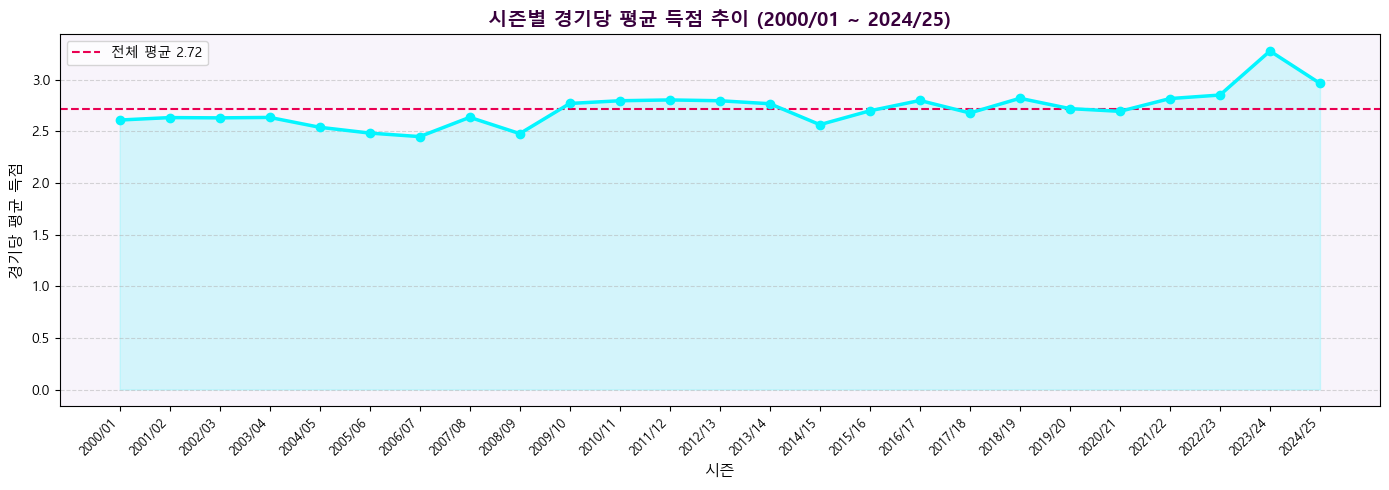

저장: 1_1_season_avg_goals.png


In [2]:
# ── 1-1. 시즌별 평균 득점 추이 ─────────────────────────────────────────────
try:
    mr = match_results.copy()
    mr['total_goals'] = mr['FullTimeHomeGoals'] + mr['FullTimeAwayGoals']
    season_goals = mr.groupby('Season')['total_goals'].mean().reset_index()
    season_goals.columns = ['Season', 'avg_goals']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(season_goals['Season'], season_goals['avg_goals'],
            color=EPL_CYAN, linewidth=2.5, marker='o', markersize=6, zorder=3)
    ax.fill_between(range(len(season_goals)), season_goals['avg_goals'],
                    alpha=0.15, color=EPL_CYAN)
    ax.set_xticks(range(len(season_goals)))
    ax.set_xticklabels(season_goals['Season'], rotation=45, ha='right', fontsize=9)
    ax.set_title('시즌별 경기당 평균 득점 추이 (2000/01 ~ 2024/25)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('경기당 평균 득점', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_facecolor('#f8f4fb')
    fig.patch.set_facecolor('white')
    # 전체 평균 참조선
    overall_avg = season_goals['avg_goals'].mean()
    ax.axhline(overall_avg, color=EPL_MAGENTA, linestyle='--', linewidth=1.5,
               label=f'전체 평균 {overall_avg:.2f}')
    ax.legend(fontsize=10)
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/1_1_season_avg_goals.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 1_1_season_avg_goals.png")
except Exception as e:
    print(f"[건너뜀] 시즌별 평균 득점 추이: {e}")


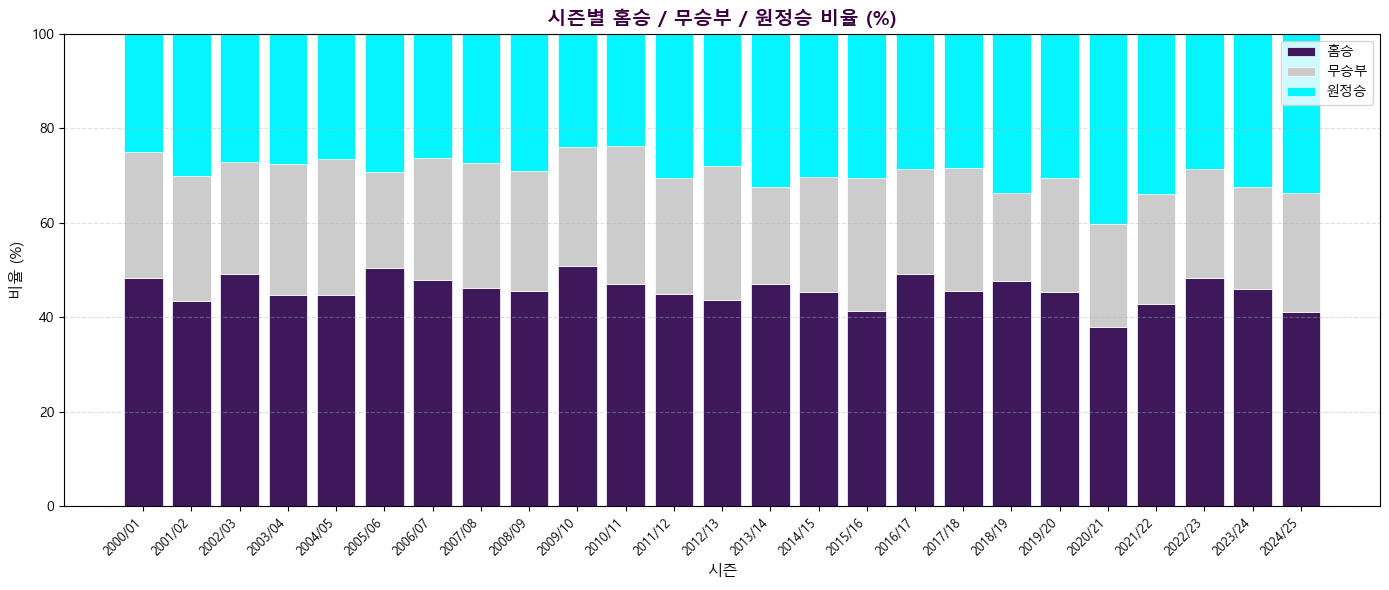

저장: 1_2_result_stacked_bar.png


In [3]:
# ── 1-2. 홈승/무승부/원정승 비율 (시즌별 누적 막대) ────────────────────────
try:
    result_map = {'H': '홈승', 'D': '무승부', 'A': '원정승'}
    mr2 = match_results.copy()
    mr2['result_kor'] = mr2['FullTimeResult'].map(result_map)
    rct = mr2.groupby(['Season', 'result_kor']).size().unstack(fill_value=0)
    # 비율로 변환
    rct_pct = rct.div(rct.sum(axis=1), axis=0) * 100

    colors_bar = [EPL_PURPLE, '#CCCCCC', EPL_CYAN]
    fig, ax = plt.subplots(figsize=(14, 6))
    bottom = np.zeros(len(rct_pct))
    labels_order = ['홈승', '무승부', '원정승']
    for i, col in enumerate(labels_order):
        if col in rct_pct.columns:
            vals = rct_pct[col].values
            ax.bar(range(len(rct_pct)), vals, bottom=bottom,
                   color=colors_bar[i], label=col, edgecolor='white', linewidth=0.5)
            bottom += vals

    ax.set_xticks(range(len(rct_pct)))
    ax.set_xticklabels(rct_pct.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('시즌별 홈승 / 무승부 / 원정승 비율 (%)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('비율 (%)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/1_2_result_stacked_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 1_2_result_stacked_bar.png")
except Exception as e:
    print(f"[건너뜀] 결과 비율 누적 막대: {e}")


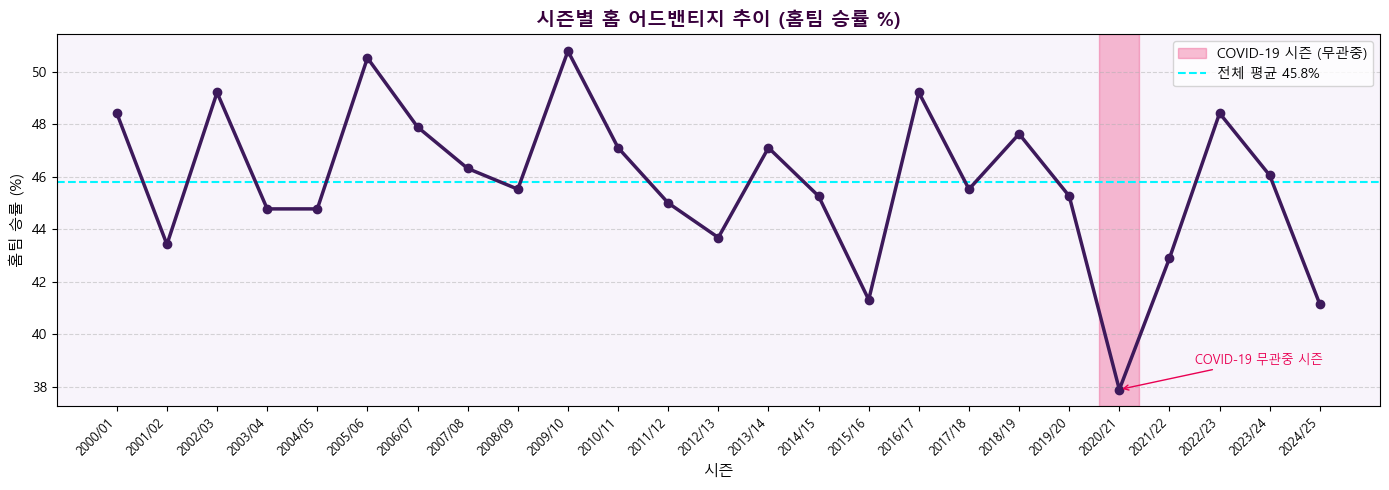

저장: 1_3_home_advantage.png


In [4]:
# ── 1-3. 홈 어드밴티지 추이 (홈승률 %, COVID 2020/21 하이라이트) ───────────
try:
    mr3 = match_results.copy()
    hw = mr3.groupby('Season').apply(
        lambda x: (x['FullTimeResult'] == 'H').sum() / len(x) * 100
    ).reset_index()
    hw.columns = ['Season', 'home_win_pct']

    fig, ax = plt.subplots(figsize=(14, 5))
    seasons_list = hw['Season'].tolist()
    covid_idx = seasons_list.index('2020/21') if '2020/21' in seasons_list else None

    ax.plot(range(len(hw)), hw['home_win_pct'], color=EPL_PURPLE,
            linewidth=2.5, marker='o', markersize=6, zorder=3)

    if covid_idx is not None:
        ax.axvspan(covid_idx - 0.4, covid_idx + 0.4, alpha=0.25,
                   color=EPL_MAGENTA, label='COVID-19 시즌 (무관중)')
        ax.annotate('COVID-19 무관중 시즌',
                    xy=(covid_idx, hw.loc[covid_idx, 'home_win_pct']),
                    xytext=(covid_idx + 1.5, hw['home_win_pct'].min() + 1),
                    arrowprops=dict(arrowstyle='->', color=EPL_MAGENTA),
                    fontsize=9, color=EPL_MAGENTA)

    overall_hw = hw['home_win_pct'].mean()
    ax.axhline(overall_hw, color=EPL_CYAN, linestyle='--', linewidth=1.5,
               label=f'전체 평균 {overall_hw:.1f}%')

    ax.set_xticks(range(len(hw)))
    ax.set_xticklabels(seasons_list, rotation=45, ha='right', fontsize=9)
    ax.set_title('시즌별 홈 어드밴티지 추이 (홈팀 승률 %)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('홈팀 승률 (%)', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_facecolor('#f8f4fb')
    ax.legend(fontsize=10)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/1_3_home_advantage.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 1_3_home_advantage.png")
except Exception as e:
    print(f"[건너뜀] 홈 어드밴티지 추이: {e}")


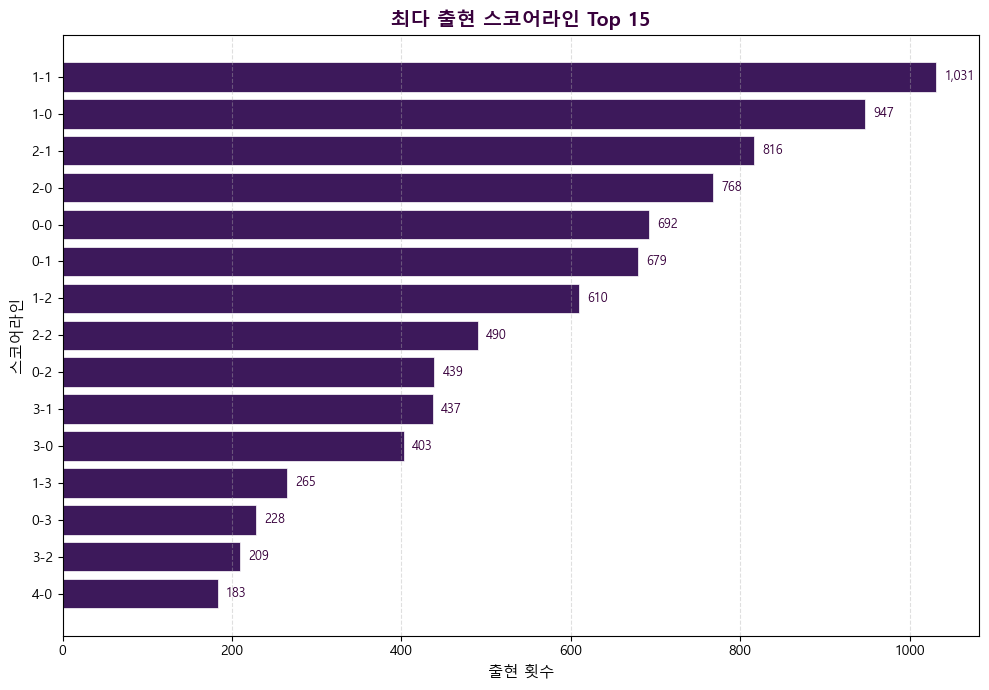

저장: 1_4_top_scorelines.png


In [5]:
# ── 1-4. 최다 출현 스코어라인 Top 15 ──────────────────────────────────────
try:
    mr4 = match_results.copy()
    mr4['scoreline'] = (mr4['FullTimeHomeGoals'].astype(str) + '-' +
                        mr4['FullTimeAwayGoals'].astype(str))
    top15 = mr4['scoreline'].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(top15.index[::-1], top15.values[::-1],
                   color=EPL_PURPLE, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, top15.values[::-1]):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9, color=EPL_DARK)
    ax.set_title('최다 출현 스코어라인 Top 15', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('출현 횟수', fontsize=11)
    ax.set_ylabel('스코어라인', fontsize=11)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/1_4_top_scorelines.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 1_4_top_scorelines.png")
except Exception as e:
    print(f"[건너뜀] 스코어라인 Top 15: {e}")


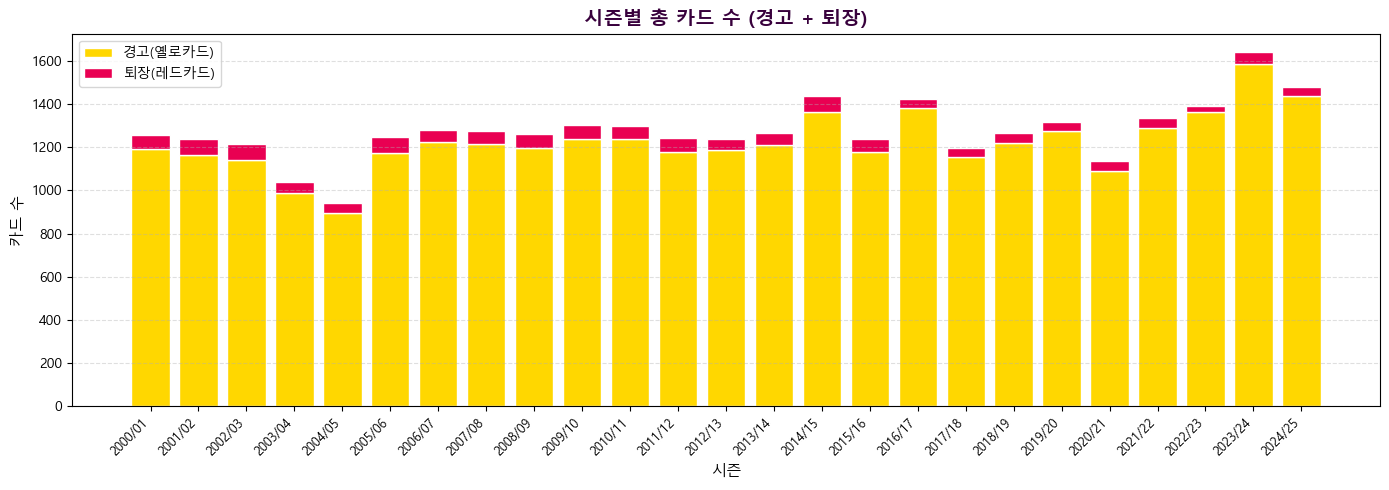

저장: 1_5_cards_by_season.png


In [6]:
# ── 1-5. 시즌별 총 카드 수 추이 (yellow + red 누적) ────────────────────────
try:
    mr5 = match_results.copy()
    mr5['total_yellow'] = mr5['HomeYellowCards'] + mr5['AwayYellowCards']
    mr5['total_red']    = mr5['HomeRedCards'] + mr5['AwayRedCards']
    card_season = mr5.groupby('Season')[['total_yellow', 'total_red']].sum().reset_index()

    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(card_season))
    ax.bar(x, card_season['total_yellow'], color='#FFD700', label='경고(옐로카드)', edgecolor='white')
    ax.bar(x, card_season['total_red'],   color=EPL_MAGENTA, label='퇴장(레드카드)',
           bottom=card_season['total_yellow'], edgecolor='white')

    ax.set_xticks(list(x))
    ax.set_xticklabels(card_season['Season'], rotation=45, ha='right', fontsize=9)
    ax.set_title('시즌별 총 카드 수 (경고 + 퇴장)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('카드 수', fontsize=11)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/1_5_cards_by_season.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 1_5_cards_by_season.png")
except Exception as e:
    print(f"[건너뜀] 카드 수 추이: {e}")


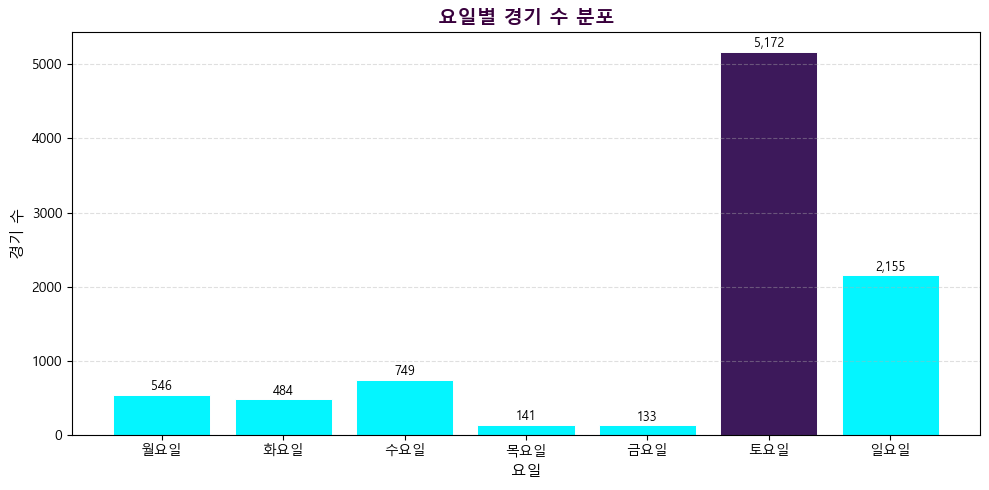

저장: 1_6_matches_by_weekday.png


In [7]:
# ── 1-6. 요일별 경기 수 분포 ────────────────────────────────────────────────
try:
    mr6 = match_results.copy()
    mr6['weekday'] = mr6['MatchDate'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_kor   = {'Monday':'월요일','Tuesday':'화요일','Wednesday':'수요일',
                 'Thursday':'목요일','Friday':'금요일','Saturday':'토요일','Sunday':'일요일'}
    day_cnt = mr6['weekday'].value_counts().reindex(day_order, fill_value=0)
    day_cnt.index = [day_kor[d] for d in day_cnt.index]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(day_cnt.index, day_cnt.values,
                  color=[EPL_PURPLE if v == day_cnt.max() else EPL_CYAN for v in day_cnt.values],
                  edgecolor='white', linewidth=0.7)
    for bar, val in zip(bars, day_cnt.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f'{val:,}', ha='center', va='bottom', fontsize=9)
    ax.set_title('요일별 경기 수 분포', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('요일', fontsize=11)
    ax.set_ylabel('경기 수', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/1_6_matches_by_weekday.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 1_6_matches_by_weekday.png")
except Exception as e:
    print(f"[건너뜀] 요일별 경기 수: {e}")


---
## 2. 팀 분석

46개 팀의 통산 성적, 빅6 순위 변화, 우승팀 포인트, 승격팀 생존 분석입니다.


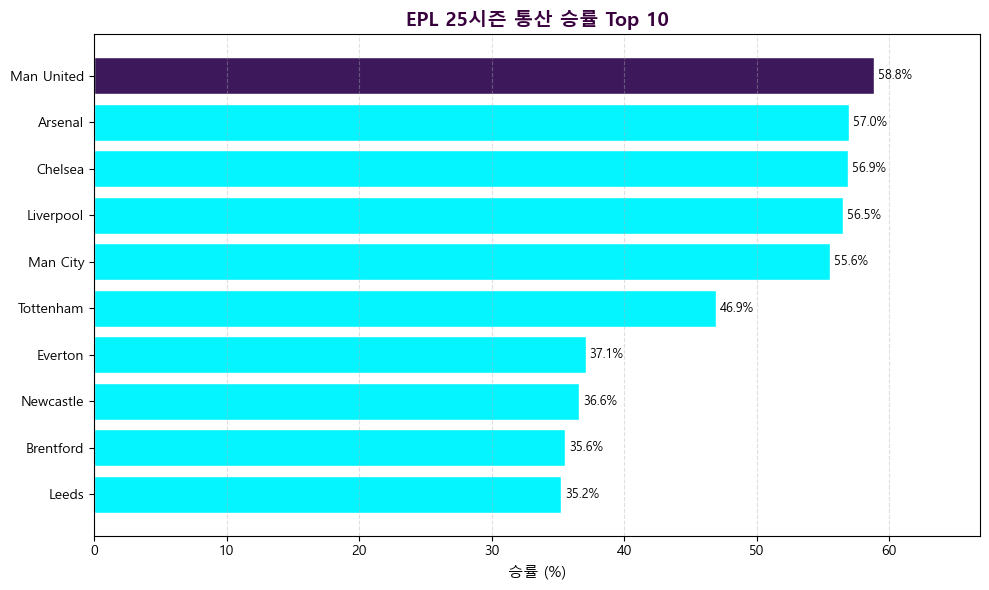

저장: 2_1_top10_win_rate.png


In [8]:
# ── 2-1. 25시즌 통산 승률 Top 10 ────────────────────────────────────────────
try:
    ts = team_season.copy()
    team_total = ts.groupby('team').agg(
        total_wins=('total_wins', 'sum'),
        total_played=('total_played', 'sum')
    ).reset_index()
    team_total['win_rate'] = team_total['total_wins'] / team_total['total_played'] * 100
    top10 = team_total.nlargest(10, 'win_rate').sort_values('win_rate')

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top10['team'], top10['win_rate'],
                   color=[EPL_PURPLE if t == top10['team'].iloc[-1] else EPL_CYAN
                          for t in top10['team']],
                   edgecolor='white')
    for bar, val in zip(bars, top10['win_rate']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title('EPL 25시즌 통산 승률 Top 10', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('승률 (%)', fontsize=11)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(0, top10['win_rate'].max() + 8)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/2_1_top10_win_rate.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 2_1_top10_win_rate.png")
except Exception as e:
    print(f"[건너뜀] 통산 승률 Top 10: {e}")


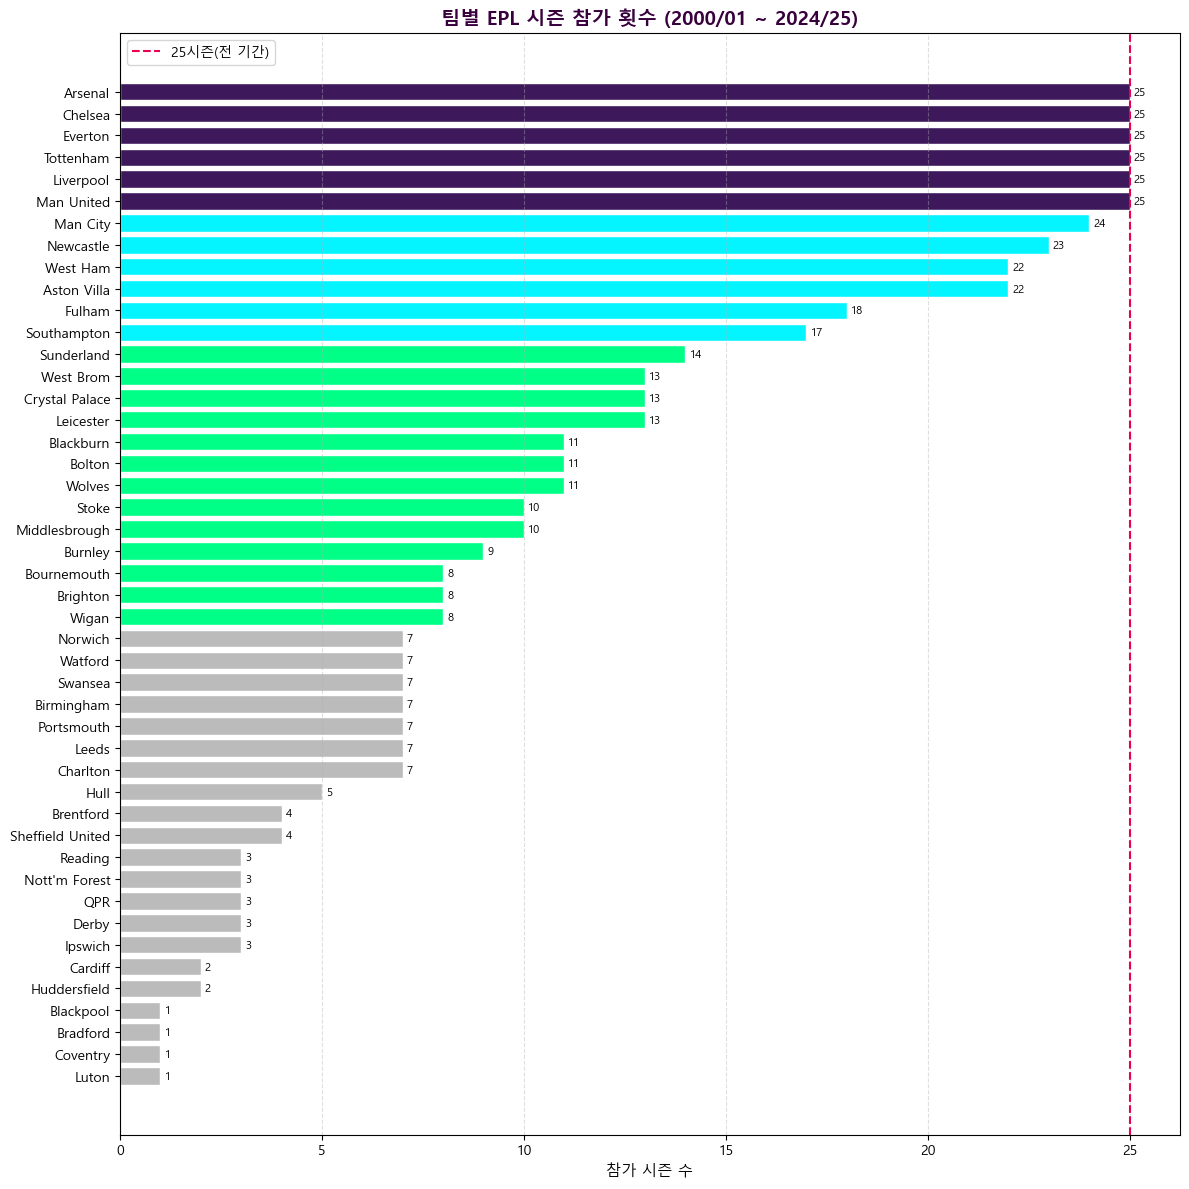

저장: 2_2_team_season_count.png


In [9]:
# ── 2-2. 팀별 시즌 참가 횟수 (전체 46개 팀) ────────────────────────────────
try:
    season_cnt = team_season['team'].value_counts().sort_values()

    fig, ax = plt.subplots(figsize=(12, 12))
    colors_46 = [EPL_PURPLE if v == 25 else
                 EPL_CYAN if v >= 15 else
                 EPL_GREEN if v >= 8 else '#BBBBBB'
                 for v in season_cnt.values]
    ax.barh(season_cnt.index, season_cnt.values, color=colors_46, edgecolor='white')
    for i, (team, val) in enumerate(zip(season_cnt.index, season_cnt.values)):
        ax.text(val + 0.1, i, str(val), va='center', fontsize=8)
    ax.set_title('팀별 EPL 시즌 참가 횟수 (2000/01 ~ 2024/25)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('참가 시즌 수', fontsize=11)
    ax.axvline(x=25, color=EPL_MAGENTA, linestyle='--', linewidth=1.5, label='25시즌(전 기간)')
    ax.legend(fontsize=10)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/2_2_team_season_count.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 2_2_team_season_count.png")
except Exception as e:
    print(f"[건너뜀] 팀별 참가 횟수: {e}")


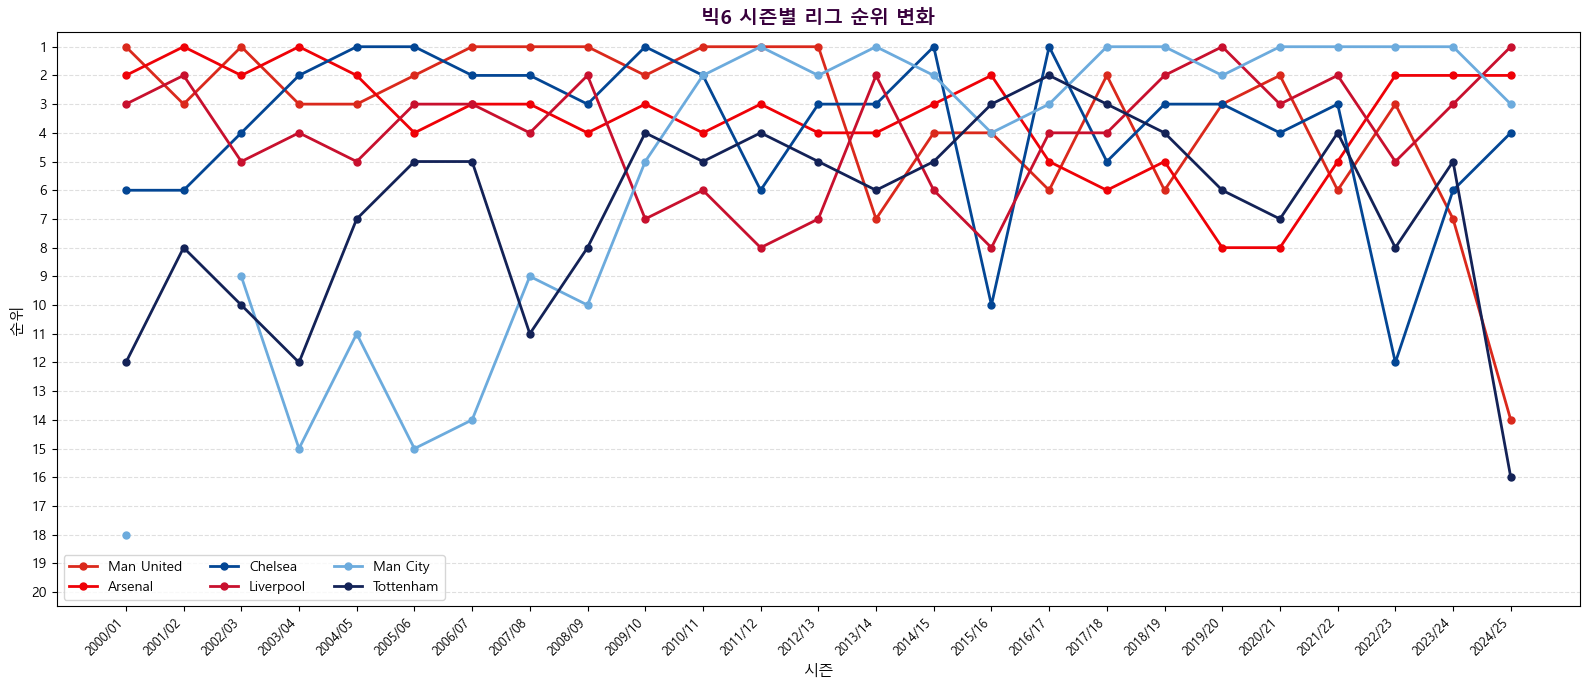

저장: 2_3_big6_rank.png


In [10]:
# ── 2-3. 빅6 시즌별 순위 변화 ──────────────────────────────────────────────
try:
    ts2 = team_season.copy()
    ts2['rank'] = ts2.groupby('Season')['points'].rank(ascending=False, method='min').astype(int)
    big6 = ['Man United', 'Arsenal', 'Chelsea', 'Liverpool', 'Man City', 'Tottenham']
    b6   = ts2[ts2['team'].isin(big6)].copy()
    seasons_sorted = sorted(b6['Season'].unique())

    big6_colors = {
        'Man United': '#DA291C',
        'Arsenal':    '#EF0107',
        'Chelsea':    '#034694',
        'Liverpool':  '#C8102E',
        'Man City':   '#6CABDD',
        'Tottenham':  '#132257',
    }

    fig, ax = plt.subplots(figsize=(16, 7))
    for team in big6:
        td = b6[b6['team'] == team].set_index('Season').reindex(seasons_sorted)
        ax.plot(range(len(seasons_sorted)), td['rank'],
                label=team, color=big6_colors[team],
                linewidth=2, marker='o', markersize=5)

    ax.set_xticks(range(len(seasons_sorted)))
    ax.set_xticklabels(seasons_sorted, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(1, 21))
    ax.set_ylim(20.5, 0.5)  # 1위가 상단
    ax.set_title('빅6 시즌별 리그 순위 변화', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('순위', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower left', fontsize=10, ncol=3)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/2_3_big6_rank.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 2_3_big6_rank.png")
except Exception as e:
    print(f"[건너뜀] 빅6 순위 변화: {e}")


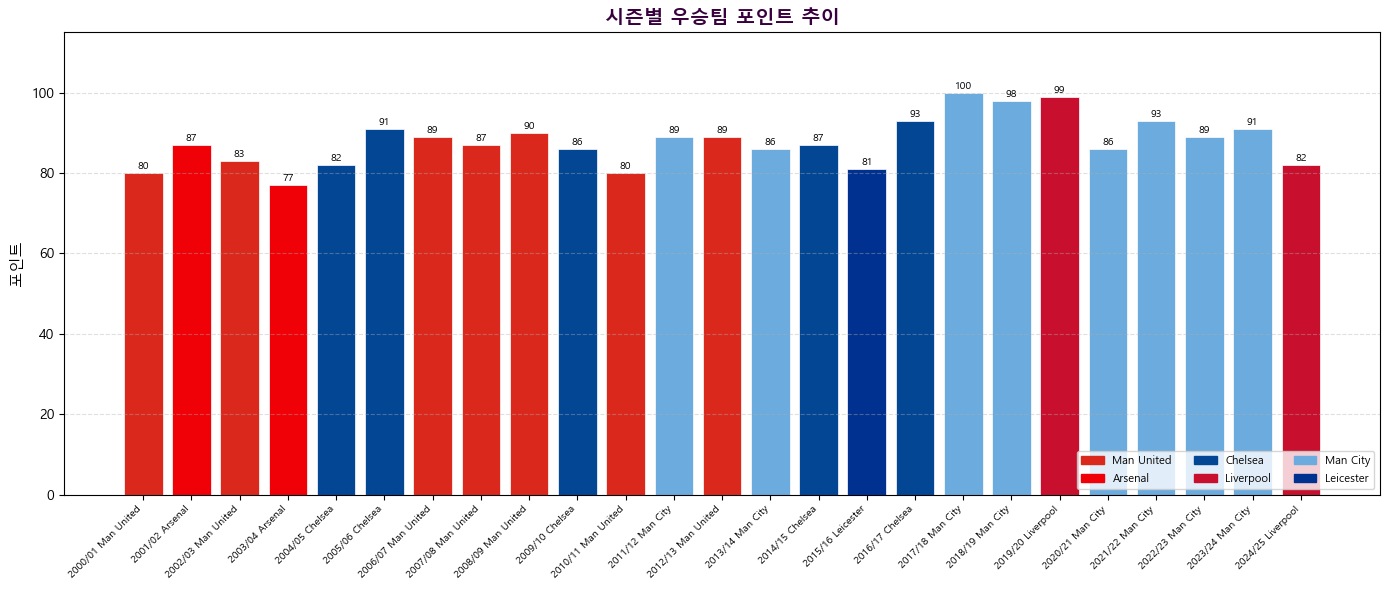

저장: 2_4_champion_points.png


In [11]:
# ── 2-4. 시즌별 우승팀 포인트 추이 ────────────────────────────────────────
try:
    ts3 = team_season.copy()
    champ_idx = ts3.groupby('Season')['points'].idxmax()
    champions = ts3.loc[champ_idx, ['Season', 'team', 'points']].reset_index(drop=True)
    champions = champions.sort_values('Season')

    team_colors_map = {
        'Man United': '#DA291C', 'Arsenal': '#EF0107', 'Chelsea': '#034694',
        'Liverpool': '#C8102E', 'Man City': '#6CABDD', 'Leicester': '#003090',
    }
    bar_colors = [team_colors_map.get(t, EPL_PURPLE) for t in champions['team']]

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(range(len(champions)), champions['points'],
                  color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, (_, row) in zip(bars, champions.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{int(row['points'])}",
                ha='center', va='bottom', fontsize=7.5, rotation=0)

    ax.set_xticks(range(len(champions)))
    ax.set_xticklabels(
        [f"{row['Season']} {row['team']}" for _, row in champions.iterrows()],
        rotation=45, ha='right', fontsize=7.5)
    ax.set_title('시즌별 우승팀 포인트 추이', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_ylabel('포인트', fontsize=11)
    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    # 범례
    handles = [mpatches.Patch(color=v, label=k) for k, v in team_colors_map.items()]
    ax.legend(handles=handles, fontsize=8, loc='lower right', ncol=3)
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/2_4_champion_points.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 2_4_champion_points.png")
except Exception as e:
    print(f"[건너뜀] 우승팀 포인트: {e}")


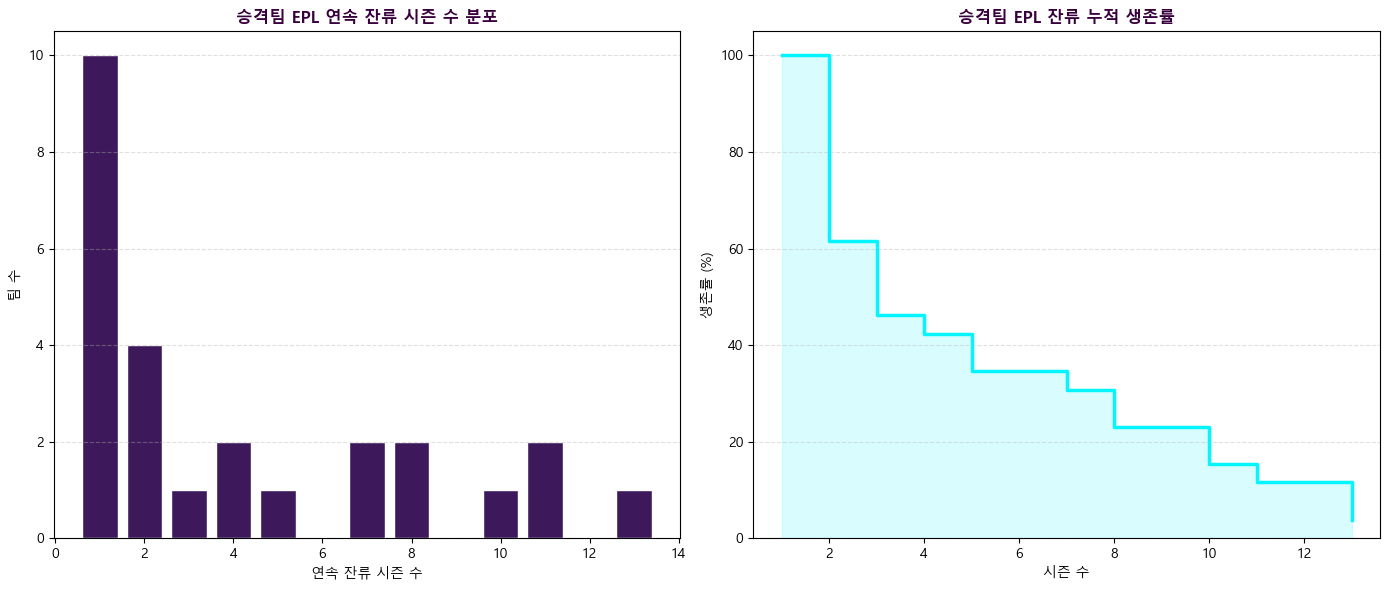

저장: 2_5_promoted_survival.png


In [12]:
# ── 2-5. 승격팀 생존률 분석 ────────────────────────────────────────────────
try:
    ts4 = team_season.copy()
    all_seasons = sorted(ts4['Season'].unique())

    # 각 팀이 처음 등장하는 시즌 탐색 (= 승격 또는 원래 EPL 팀)
    # 2000/01 이후에 처음 등장한 팀 = 승격팀으로 간주
    first_seasons = ts4.groupby('team')['Season'].min().reset_index()
    first_seasons.columns = ['team', 'first_season']
    # 2000/01에 이미 있던 팀 제외
    promoted = first_seasons[first_seasons['first_season'] != '2000/01'].copy()

    # 각 승격팀의 연속 잔류 시즌 수 계산
    def count_consec_seasons(team, start_season):
        team_data = ts4[ts4['team'] == team]['Season'].tolist()
        idx = all_seasons.index(start_season)
        count = 0
        for s in all_seasons[idx:]:
            if s in team_data:
                count += 1
            else:
                break
        return count

    promoted['consec_seasons'] = promoted.apply(
        lambda r: count_consec_seasons(r['team'], r['first_season']), axis=1)

    # 생존 시즌 수 분포
    survival_cnt = promoted['consec_seasons'].value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 왼쪽: 생존 시즌 수 분포 막대
    axes[0].bar(survival_cnt.index, survival_cnt.values,
                color=EPL_PURPLE, edgecolor='white')
    axes[0].set_title('승격팀 EPL 연속 잔류 시즌 수 분포', fontsize=12, fontweight='bold', color=EPL_DARK)
    axes[0].set_xlabel('연속 잔류 시즌 수', fontsize=10)
    axes[0].set_ylabel('팀 수', fontsize=10)
    axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)

    # 오른쪽: 누적 생존률 (kaplan-meier 스타일)
    total = len(promoted)
    x_vals = sorted(survival_cnt.index.tolist())
    survived = [(promoted['consec_seasons'] >= x).sum() / total * 100 for x in x_vals]
    axes[1].step(x_vals, survived, color=EPL_CYAN, linewidth=2.5, where='post')
    axes[1].fill_between(x_vals, survived, step='post', alpha=0.15, color=EPL_CYAN)
    axes[1].set_title('승격팀 EPL 잔류 누적 생존률', fontsize=12, fontweight='bold', color=EPL_DARK)
    axes[1].set_xlabel('시즌 수', fontsize=10)
    axes[1].set_ylabel('생존률 (%)', fontsize=10)
    axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
    axes[1].set_ylim(0, 105)

    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/2_5_promoted_survival.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 2_5_promoted_survival.png")
except Exception as e:
    print(f"[건너뜀] 승격팀 생존률: {e}")


---
## 3. 선수 스탯 분석

14,980건의 선수-시즌 레코드 기반 연령, 포지션, 국적, 득점 분석입니다.


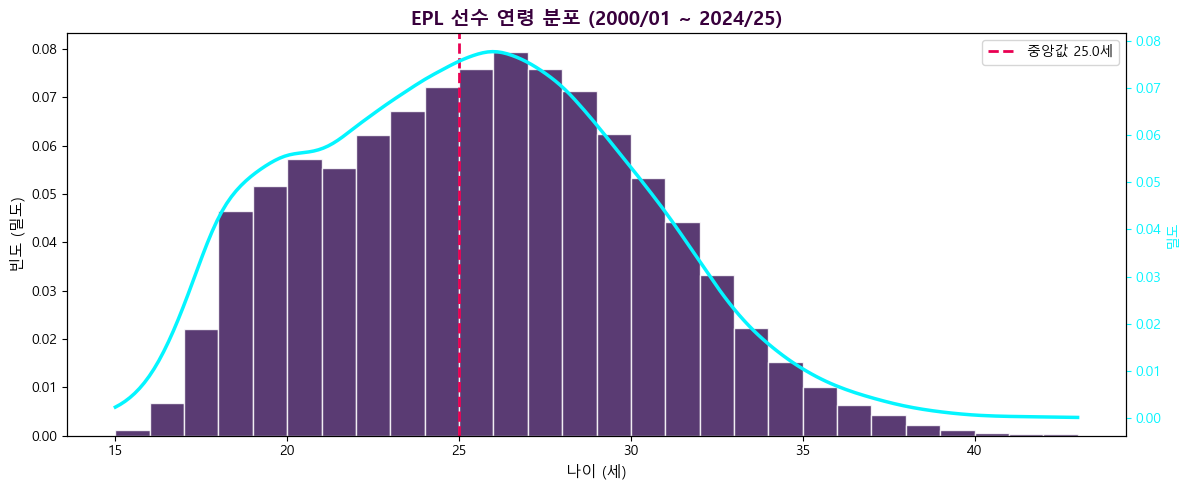

저장: 3_1_age_distribution.png


In [13]:
# ── 3-1. 연령 분포 히스토그램 (KDE 포함) ───────────────────────────────────
try:
    ps = player_season.copy()
    ages = ps['age'].dropna()
    ages = ages[(ages >= 15) & (ages <= 43)]

    fig, ax = plt.subplots(figsize=(12, 5))
    n, bins, patches = ax.hist(ages, bins=28, color=EPL_PURPLE,
                               edgecolor='white', alpha=0.85, density=True)
    # KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(ages)
    x_range = np.linspace(ages.min(), ages.max(), 200)
    ax2 = ax.twinx()
    ax2.plot(x_range, kde(x_range), color=EPL_CYAN, linewidth=2.5, label='KDE')
    ax2.set_ylabel('밀도', fontsize=10, color=EPL_CYAN)
    ax2.tick_params(axis='y', colors=EPL_CYAN)

    median_age = ages.median()
    ax.axvline(median_age, color=EPL_MAGENTA, linestyle='--', linewidth=2,
               label=f'중앙값 {median_age:.1f}세')
    ax.set_title('EPL 선수 연령 분포 (2000/01 ~ 2024/25)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('나이 (세)', fontsize=11)
    ax.set_ylabel('빈도 (밀도)', fontsize=11)
    ax.legend(fontsize=10)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/3_1_age_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 3_1_age_distribution.png")
except Exception as e:
    print(f"[건너뜀] 연령 분포: {e}")


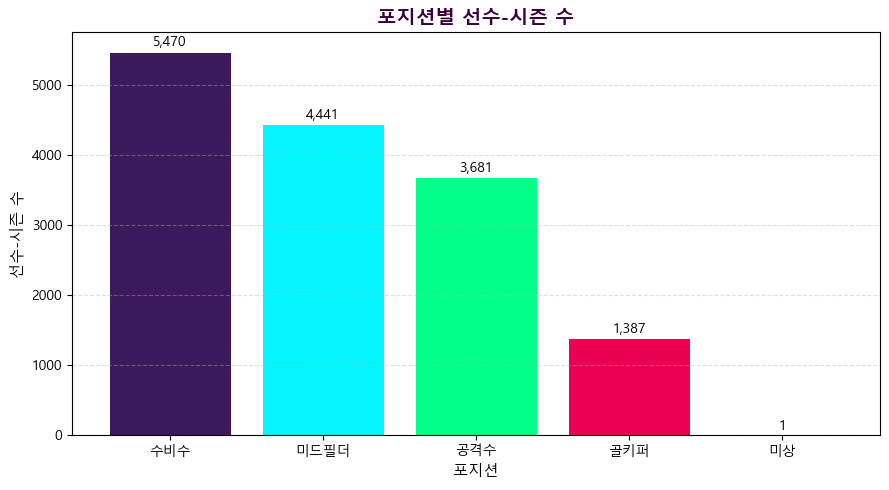

저장: 3_2_position_count.png


In [14]:
# ── 3-2. 포지션별 선수 수 (fbref pos 기준) ──────────────────────────────────
try:
    ps2 = player_season.copy()
    # 첫 번째 포지션만 사용
    ps2['pos_main'] = ps2['pos'].fillna('Unknown').apply(lambda x: x.split(',')[0])
    pos_map = {'GK':'골키퍼', 'DF':'수비수', 'MF':'미드필더', 'FW':'공격수', 'Unknown':'미상'}
    ps2['pos_kor'] = ps2['pos_main'].map(pos_map).fillna(ps2['pos_main'])
    pos_cnt = ps2['pos_kor'].value_counts()

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(pos_cnt.index, pos_cnt.values,
                  color=[EPL_PURPLE, EPL_CYAN, EPL_GREEN, EPL_MAGENTA, '#BBBBBB'][:len(pos_cnt)],
                  edgecolor='white', linewidth=0.7)
    for bar, val in zip(bars, pos_cnt.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{val:,}', ha='center', va='bottom', fontsize=10)
    ax.set_title('포지션별 선수-시즌 수', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('포지션', fontsize=11)
    ax.set_ylabel('선수-시즌 수', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/3_2_position_count.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 3_2_position_count.png")
except Exception as e:
    print(f"[건너뜀] 포지션별 선수 수: {e}")


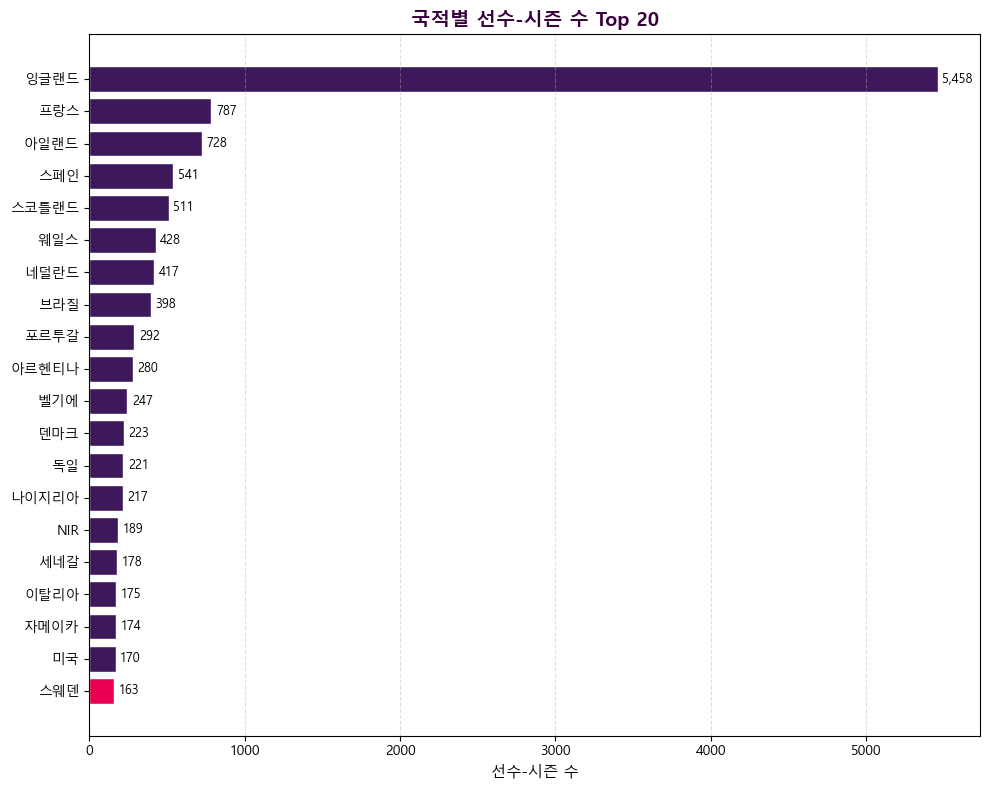

저장: 3_3_nationality_top20.png


In [15]:
# ── 3-3. 국적 Top 20 ────────────────────────────────────────────────────────
try:
    ps3 = player_season.copy()
    # nation 컬럼에서 3자리 국가코드 추출
    ps3['nation_code'] = ps3['nation'].fillna('').str.extract(r'([A-Z]{3})')
    nat_cnt = ps3['nation_code'].value_counts().dropna().head(20)
    # 영문 코드 → 한국어 매핑 일부
    nat_kor = {
        'ENG':'잉글랜드','FRA':'프랑스','BRA':'브라질','ESP':'스페인','GER':'독일',
        'ARG':'아르헨티나','IRL':'아일랜드','SCO':'스코틀랜드','NED':'네덜란드','POR':'포르투갈',
        'WAL':'웨일스','NGA':'나이지리아','SEN':'세네갈','ITA':'이탈리아','BEL':'벨기에',
        'CMR':'카메룬','CIV':'코트디부아르','USA':'미국','GHA':'가나','URU':'우루과이',
        'DEN':'덴마크','SWE':'스웨덴','NOR':'노르웨이','AUS':'호주','JAM':'자메이카',
    }
    nat_cnt.index = [nat_kor.get(c, c) for c in nat_cnt.index]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(nat_cnt.index[::-1], nat_cnt.values[::-1],
                   color=[EPL_MAGENTA if i == 0 else EPL_PURPLE for i in range(len(nat_cnt))],
                   edgecolor='white')
    for bar, val in zip(bars, nat_cnt.values[::-1]):
        ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9)
    ax.set_title('국적별 선수-시즌 수 Top 20', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('선수-시즌 수', fontsize=11)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/3_3_nationality_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 3_3_nationality_top20.png")
except Exception as e:
    print(f"[건너뜀] 국적 Top 20: {e}")


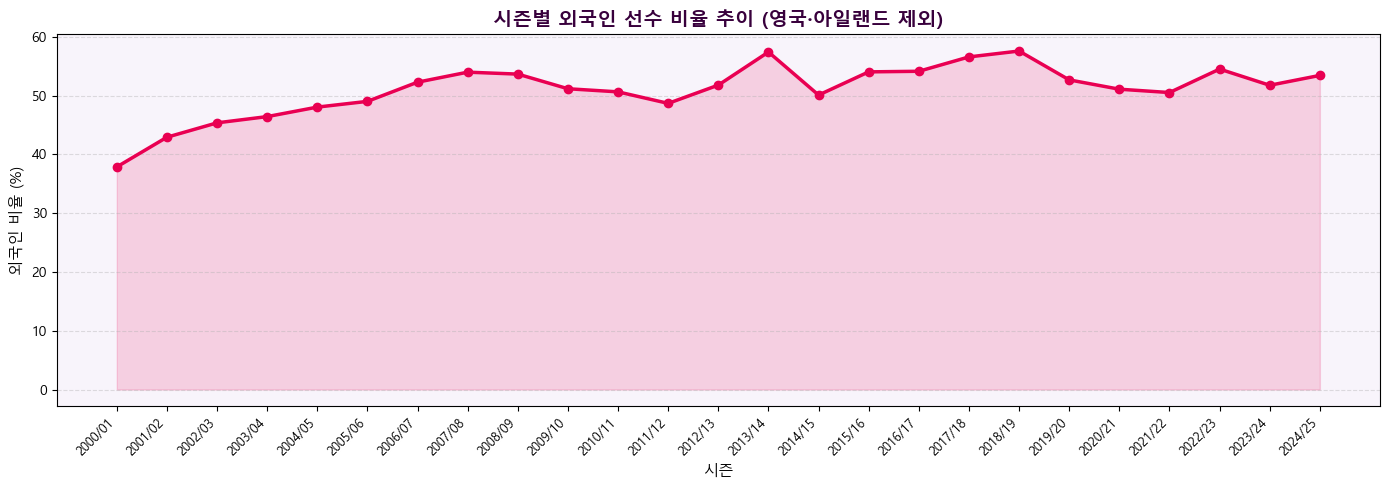

저장: 3_4_foreign_player_ratio.png


In [16]:
# ── 3-4. 시즌별 외국인 선수 비율 추이 ──────────────────────────────────────
try:
    ps4 = player_season.copy()
    ps4['nation_code'] = ps4['nation'].fillna('').str.extract(r'([A-Z]{3})')
    ps4['is_foreign'] = ~ps4['nation_code'].isin(['ENG', 'SCO', 'WAL', 'NIR', 'IRL'])
    foreign_pct = ps4.groupby('season').apply(
        lambda x: x['is_foreign'].sum() / len(x) * 100
    ).reset_index()
    foreign_pct.columns = ['season', 'foreign_pct']
    foreign_pct = foreign_pct.sort_values('season')

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(range(len(foreign_pct)), foreign_pct['foreign_pct'],
            color=EPL_MAGENTA, linewidth=2.5, marker='o', markersize=6)
    ax.fill_between(range(len(foreign_pct)), foreign_pct['foreign_pct'],
                    alpha=0.15, color=EPL_MAGENTA)
    ax.set_xticks(range(len(foreign_pct)))
    ax.set_xticklabels(foreign_pct['season'], rotation=45, ha='right', fontsize=9)
    ax.set_title('시즌별 외국인 선수 비율 추이 (영국·아일랜드 제외)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('외국인 비율 (%)', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_facecolor('#f8f4fb')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/3_4_foreign_player_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 3_4_foreign_player_ratio.png")
except Exception as e:
    print(f"[건너뜀] 외국인 선수 비율: {e}")


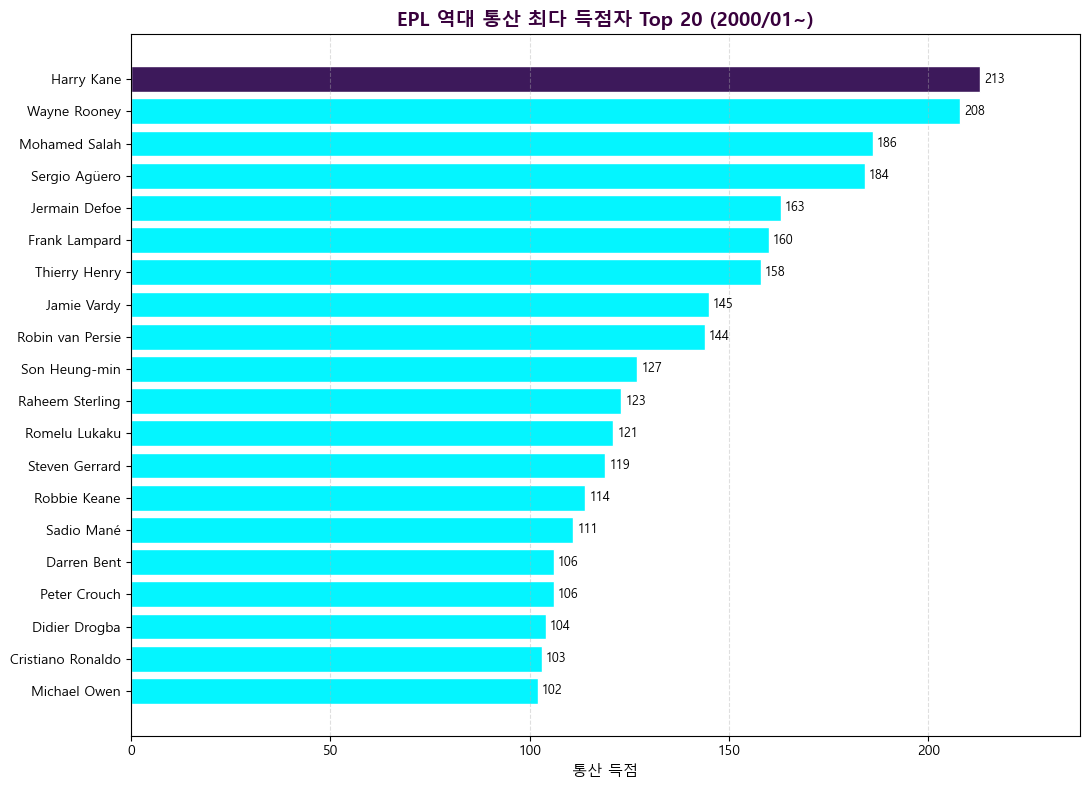

저장: 3_5_top20_scorers.png


In [17]:
# ── 3-5. 통산 최다 득점자 Top 20 ───────────────────────────────────────────
try:
    pa = player_alltime.copy()
    top20 = pa.nlargest(20, 'gls').sort_values('gls')

    fig, ax = plt.subplots(figsize=(11, 8))
    bars = ax.barh(top20['player'], top20['gls'],
                   color=[EPL_PURPLE if v == top20['gls'].max() else EPL_CYAN
                          for v in top20['gls']],
                   edgecolor='white')
    for bar, val in zip(bars, top20['gls']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                str(int(val)), va='center', fontsize=9)
    ax.set_title('EPL 역대 통산 최다 득점자 Top 20 (2000/01~)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('통산 득점', fontsize=11)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(0, top20['gls'].max() + 25)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/3_5_top20_scorers.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 3_5_top20_scorers.png")
except Exception as e:
    print(f"[건너뜀] 통산 최다 득점자: {e}")


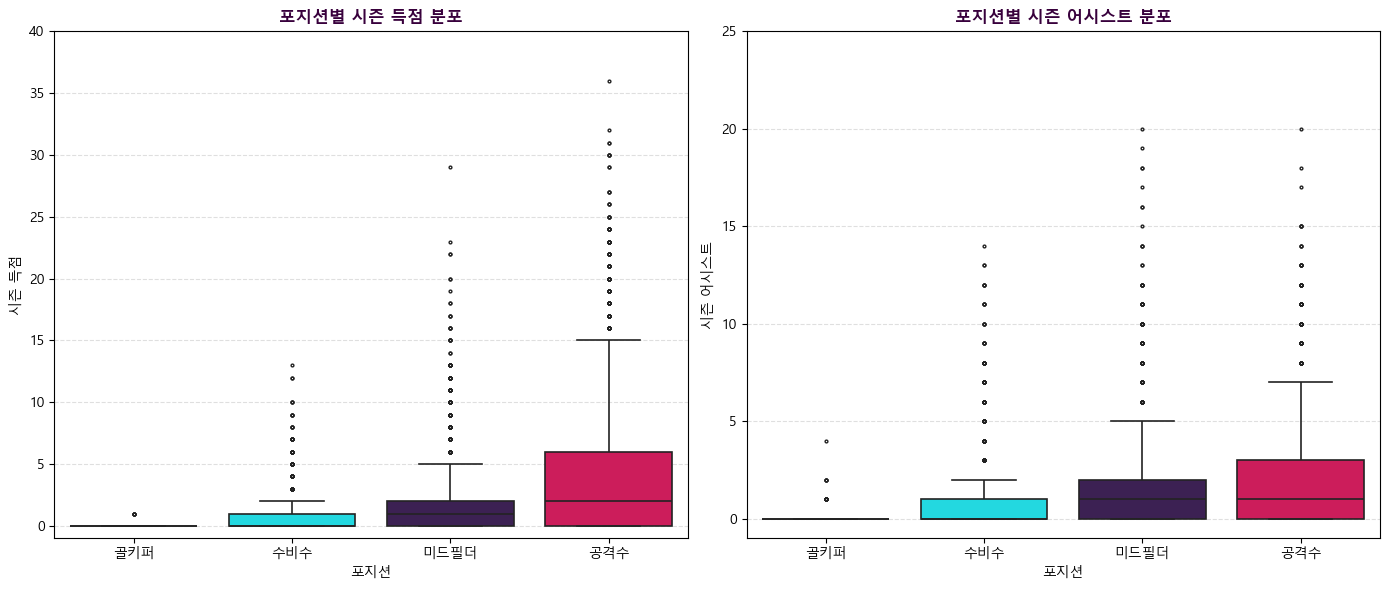

저장: 3_6_pos_goals_assists_boxplot.png


In [18]:
# ── 3-6. 포지션별 골/어시스트 분포 (Box plot) ──────────────────────────────
try:
    ps6 = player_season.copy()
    ps6['pos_main'] = ps6['pos'].fillna('Unknown').apply(lambda x: x.split(',')[0])
    pos_filter = ['GK', 'DF', 'MF', 'FW']
    pos_kor_map = {'GK':'골키퍼','DF':'수비수','MF':'미드필더','FW':'공격수'}
    ps6 = ps6[ps6['pos_main'].isin(pos_filter)].copy()
    ps6['pos_kor'] = ps6['pos_main'].map(pos_kor_map)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    order_kor = ['골키퍼', '수비수', '미드필더', '공격수']
    pal = {'골키퍼': '#AAAAAA', '수비수': EPL_CYAN, '미드필더': EPL_PURPLE, '공격수': EPL_MAGENTA}

    sns.boxplot(data=ps6, x='pos_kor', y='gls', order=order_kor, palette=pal,
                ax=axes[0], fliersize=2, linewidth=1.2)
    axes[0].set_title('포지션별 시즌 득점 분포', fontsize=12, fontweight='bold', color=EPL_DARK)
    axes[0].set_xlabel('포지션', fontsize=10)
    axes[0].set_ylabel('시즌 득점', fontsize=10)
    axes[0].set_ylim(-1, 40)
    axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)

    sns.boxplot(data=ps6, x='pos_kor', y='ast', order=order_kor, palette=pal,
                ax=axes[1], fliersize=2, linewidth=1.2)
    axes[1].set_title('포지션별 시즌 어시스트 분포', fontsize=12, fontweight='bold', color=EPL_DARK)
    axes[1].set_xlabel('포지션', fontsize=10)
    axes[1].set_ylabel('시즌 어시스트', fontsize=10)
    axes[1].set_ylim(-1, 25)
    axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)

    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/3_6_pos_goals_assists_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 3_6_pos_goals_assists_boxplot.png")
except Exception as e:
    print(f"[건너뜀] 포지션별 골/어시스트: {e}")


---
## 4. 경기별 스탯 심층 분석

299,517건의 선수-경기 로그를 활용한 출전 패턴, 슈팅/패스/태클, 시대별 데이터 가용성, 포지션 레이더 차트.


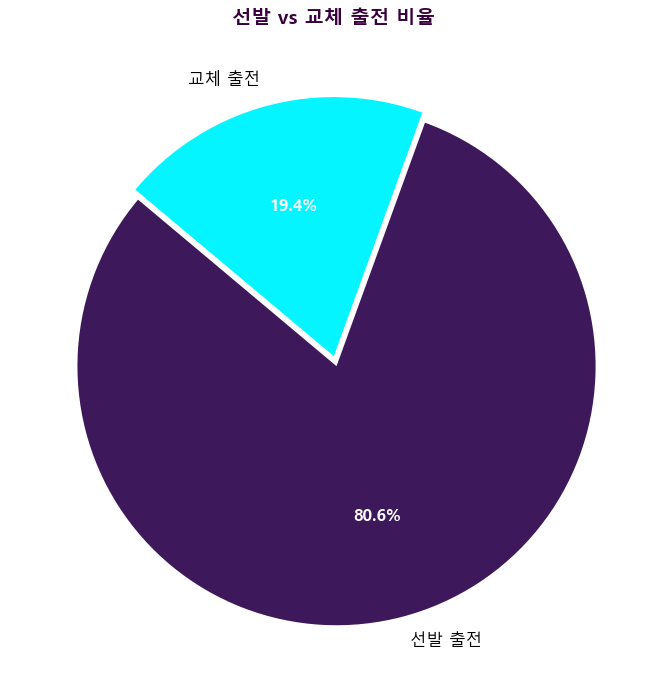

저장: 4_1_start_vs_sub.png


In [19]:
# ── 4-1. 선발/교체 출전 비율 (Pie chart) ────────────────────────────────────
try:
    pml = player_match_logs.copy()
    # 실제 출전한 선수만 (포지션 기록 있고, 분 > 0)
    played = pml[(pml['min'].fillna(0) > 0) | (pml['gls'].notna())]
    played = played[played['pos'] != 'On matchday squad, but did not play'].copy()
    started_cnt = played['started'].value_counts()
    labels = ['선발 출전', '교체 출전']
    sizes  = [started_cnt.get(True, 0), started_cnt.get(False, 0)]
    colors_pie = [EPL_PURPLE, EPL_CYAN]
    explode = (0.04, 0)

    fig, ax = plt.subplots(figsize=(8, 7))
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                      colors=colors_pie, explode=explode,
                                      startangle=140, textprops={'fontsize': 12})
    for at in autotexts:
        at.set_color('white')
        at.set_fontweight('bold')
    ax.set_title('선발 vs 교체 출전 비율', fontsize=14, fontweight='bold', color=EPL_DARK)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/4_1_start_vs_sub.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 4_1_start_vs_sub.png")
except Exception as e:
    print(f"[건너뜀] 선발/교체 비율: {e}")


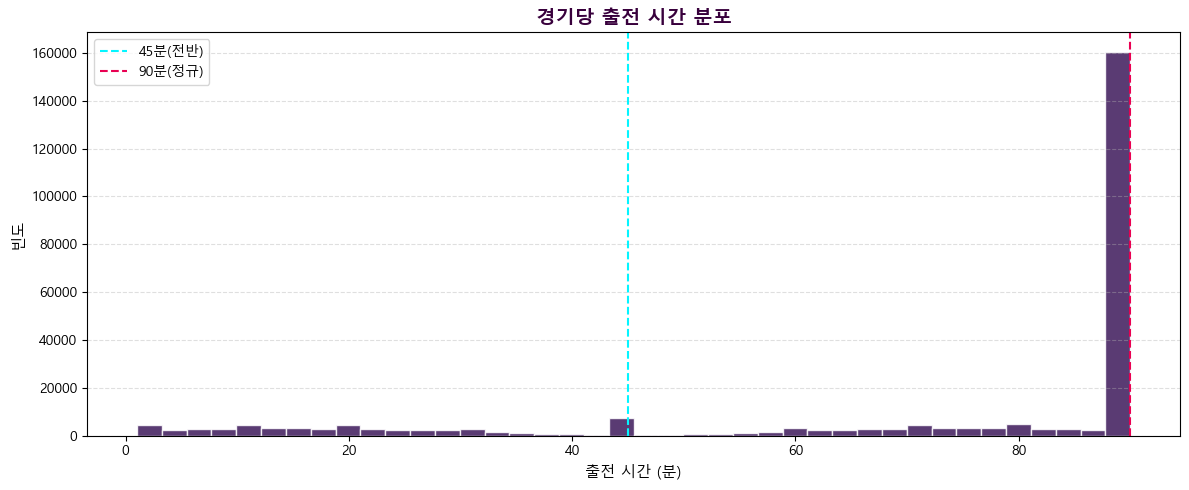

저장: 4_2_minutes_distribution.png


In [20]:
# ── 4-2. 출전 시간 분포 (histogram) ─────────────────────────────────────────
try:
    pml2 = player_match_logs.copy()
    mins = pml2['min'].dropna()
    mins = mins[(mins > 0) & (mins <= 120)]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(mins, bins=40, color=EPL_PURPLE, edgecolor='white', alpha=0.85)
    ax.axvline(45,  color=EPL_CYAN,    linestyle='--', linewidth=1.5, label='45분(전반)')
    ax.axvline(90,  color=EPL_MAGENTA, linestyle='--', linewidth=1.5, label='90분(정규)')
    ax.set_title('경기당 출전 시간 분포', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('출전 시간 (분)', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/4_2_minutes_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 4_2_minutes_distribution.png")
except Exception as e:
    print(f"[건너뜀] 출전 시간 분포: {e}")


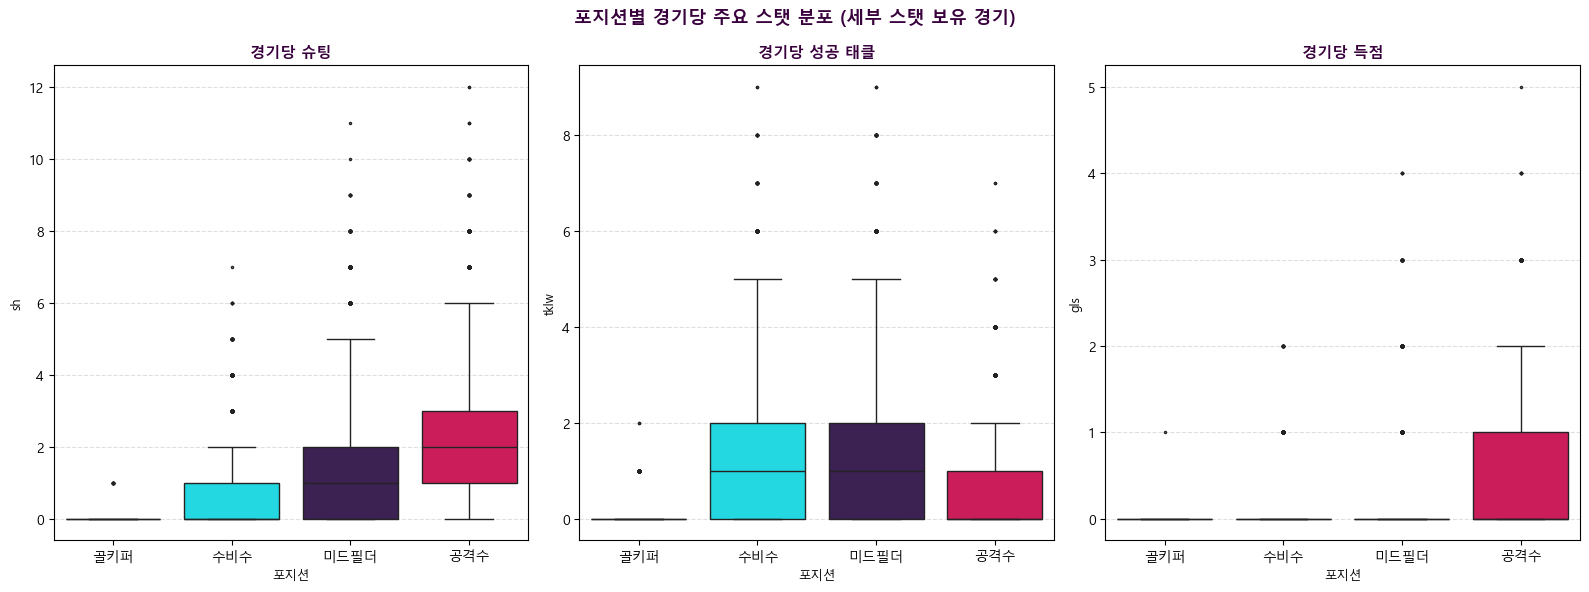

저장: 4_3_stats_by_position_box.png


In [21]:
# ── 4-3. 경기당 슈팅/어시스트/태클 분포 (포지션별 Box plot) ───────────────
try:
    pml3 = player_match_logs.copy()
    pos_map4 = {'GK':'골키퍼','DF':'수비수','CB':'수비수','LB':'수비수','RB':'수비수',
                'MF':'미드필더','CM':'미드필더','DM':'미드필더','AM':'미드필더',
                'LM':'미드필더','RM':'미드필더','FW':'공격수','LW':'공격수','RW':'공격수'}
    pml3['pos_kor'] = pml3['pos'].map(pos_map4)
    pml3 = pml3[pml3['pos_kor'].notna() & (pml3['detail_stats_available'] == True)].copy()
    order4 = ['골키퍼', '수비수', '미드필더', '공격수']
    pal4   = {'골키퍼':'#AAAAAA','수비수':EPL_CYAN,'미드필더':EPL_PURPLE,'공격수':EPL_MAGENTA}

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    for ax_i, (col, title) in enumerate(zip(['sh', 'tklw', 'gls'],
                                            ['경기당 슈팅', '경기당 성공 태클', '경기당 득점'])):
        if col in pml3.columns:
            data_col = pml3[pml3[col].notna()]
            sns.boxplot(data=data_col, x='pos_kor', y=col, order=order4, palette=pal4,
                        ax=axes[ax_i], fliersize=1.5, linewidth=1)
            axes[ax_i].set_title(title, fontsize=11, fontweight='bold', color=EPL_DARK)
            axes[ax_i].set_xlabel('포지션', fontsize=9)
            axes[ax_i].set_ylabel(col, fontsize=9)
            axes[ax_i].yaxis.grid(True, linestyle='--', alpha=0.4)
        else:
            axes[ax_i].text(0.5, 0.5, f'{col} 컬럼 없음', ha='center', va='center')

    fig.suptitle('포지션별 경기당 주요 스탯 분포 (세부 스탯 보유 경기)', fontsize=13, fontweight='bold', color=EPL_DARK)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/4_3_stats_by_position_box.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 4_3_stats_by_position_box.png")
except Exception as e:
    print(f"[건너뜀] 포지션별 스탯 분포: {e}")


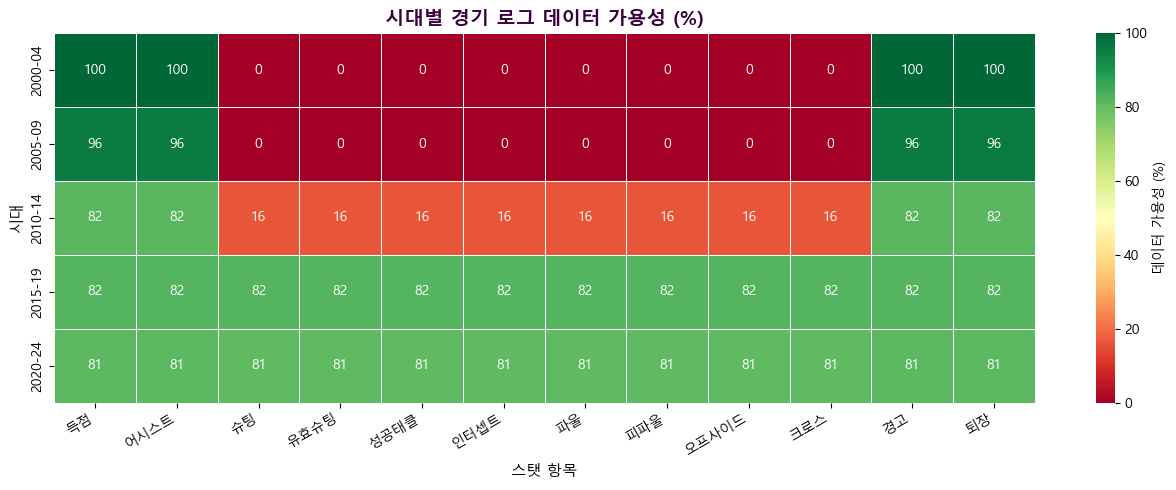

저장: 4_4_data_availability_heatmap.png


In [22]:
# ── 4-4. 시대별 데이터 가용성 히트맵 ───────────────────────────────────────
try:
    pml4 = player_match_logs.copy()
    key_cols = ['gls','ast','sh','sot','tklw','int','fls','fld','off','crs','crdy','crdr']
    key_cols = [c for c in key_cols if c in pml4.columns]
    pml4['season_year'] = pml4['season'].str[:4].astype(int)
    era_bins = list(range(2000, 2026, 5))
    era_labels = ['2000-04','2005-09','2010-14','2015-19','2020-24']
    pml4['era'] = pd.cut(pml4['season_year'], bins=era_bins, labels=era_labels, right=False)
    avail = pml4.groupby('era')[key_cols].apply(lambda g: g.notna().mean() * 100)

    col_kor = {'gls':'득점','ast':'어시스트','sh':'슈팅','sot':'유효슈팅',
               'tklw':'성공태클','int':'인터셉트','fls':'파울','fld':'피파울',
               'off':'오프사이드','crs':'크로스','crdy':'경고','crdr':'퇴장'}
    avail.columns = [col_kor.get(c, c) for c in avail.columns]

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(avail, annot=True, fmt='.0f', cmap='RdYlGn',
                vmin=0, vmax=100, ax=ax, linewidths=0.5,
                annot_kws={'size': 10}, cbar_kws={'label': '데이터 가용성 (%)'})
    ax.set_title('시대별 경기 로그 데이터 가용성 (%)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('스탯 항목', fontsize=11)
    ax.set_ylabel('시대', fontsize=11)
    plt.xticks(rotation=30, ha='right', fontsize=10)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/4_4_data_availability_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 4_4_data_availability_heatmap.png")
except Exception as e:
    print(f"[건너뜀] 데이터 가용성 히트맵: {e}")


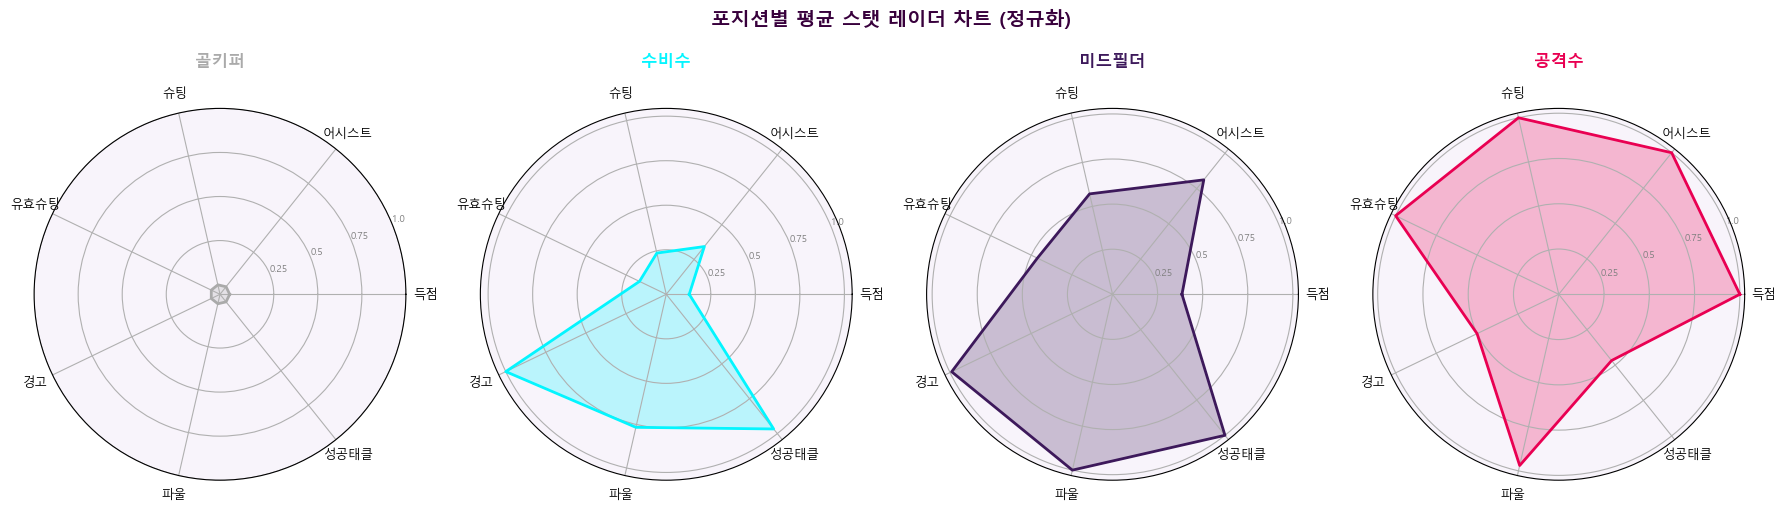

저장: 4_5_radar_chart.png


In [23]:
# ── 4-5. 포지션별 평균 스탯 레이더 차트 ────────────────────────────────────
try:
    import matplotlib.patches as mpatches
    pml5 = player_match_logs.copy()
    pml5 = pml5[pml5['detail_stats_available'] == True].copy()
    pos_map5 = {'GK':'GK','DF':'DF','CB':'DF','LB':'DF','RB':'DF',
                'MF':'MF','CM':'MF','DM':'MF','AM':'MF','LM':'MF','RM':'MF',
                'FW':'FW','LW':'FW','RW':'FW'}
    pml5['pos_group'] = pml5['pos'].map(pos_map5)
    pml5 = pml5[pml5['pos_group'].notna()].copy()

    radar_cols = ['gls','ast','sh','sot','crdy','fls','tklw']
    radar_cols = [c for c in radar_cols if c in pml5.columns]
    radar_kor  = {'gls':'득점','ast':'어시스트','sh':'슈팅','sot':'유효슈팅',
                  'crdy':'경고','fls':'파울','tklw':'성공태클'}

    pos_means = pml5.groupby('pos_group')[radar_cols].mean()
    # 정규화 (0~1)
    norm = (pos_means - pos_means.min()) / (pos_means.max() - pos_means.min() + 1e-9)

    categories = [radar_kor.get(c, c) for c in radar_cols]
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    pos_colors = {'GK': '#AAAAAA', 'DF': EPL_CYAN, 'MF': EPL_PURPLE, 'FW': EPL_MAGENTA}
    pos_kor5 = {'GK':'골키퍼','DF':'수비수','MF':'미드필더','FW':'공격수'}

    fig, axes = plt.subplots(1, 4, figsize=(18, 5), subplot_kw=dict(polar=True))
    for ax_i, pos in enumerate(['GK', 'DF', 'MF', 'FW']):
        if pos not in norm.index:
            axes[ax_i].set_title(f'{pos_kor5[pos]} (데이터 없음)', fontsize=10)
            continue
        values = norm.loc[pos].tolist()
        values += values[:1]
        ax_r = axes[ax_i]
        ax_r.plot(angles, values, color=pos_colors[pos], linewidth=2)
        ax_r.fill(angles, values, color=pos_colors[pos], alpha=0.25)
        ax_r.set_xticks(angles[:-1])
        ax_r.set_xticklabels(categories, fontsize=9)
        ax_r.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax_r.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=7, color='grey')
        ax_r.set_title(pos_kor5[pos], fontsize=12, fontweight='bold',
                       color=pos_colors[pos], pad=15)
        ax_r.set_facecolor('#f8f4fb')

    fig.suptitle('포지션별 평균 스탯 레이더 차트 (정규화)', fontsize=14, fontweight='bold', color=EPL_DARK, y=1.02)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/4_5_radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 4_5_radar_chart.png")
except Exception as e:
    print(f"[건너뜀] 레이더 차트: {e}")


---
## 5. 몸값 분석

Transfermarkt 기반 몸값 데이터 분석 (0값 제외, 유효 데이터 약 11,244건).


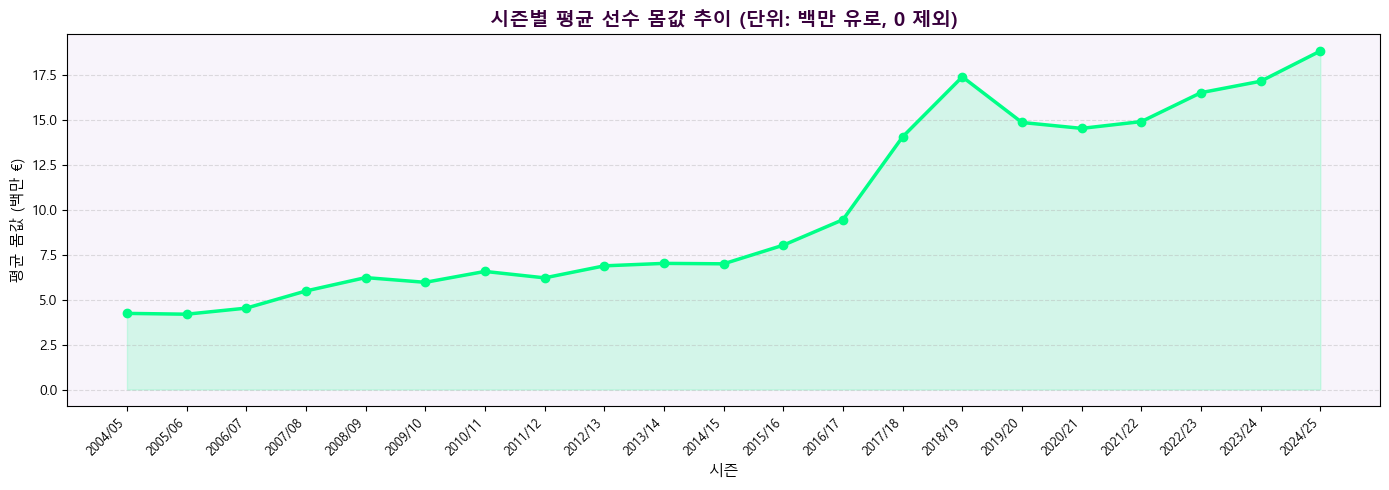

저장: 5_1_avg_market_value.png


In [24]:
# ── 5-1. 시즌별 평균 몸값 추이 ─────────────────────────────────────────────
try:
    ps_mv = player_season[player_season['market_value'] > 0].copy()
    mv_season = ps_mv.groupby('season')['market_value'].mean().reset_index()
    mv_season = mv_season.sort_values('season')
    mv_season['mv_M'] = mv_season['market_value'] / 1e6

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(range(len(mv_season)), mv_season['mv_M'],
            color=EPL_GREEN, linewidth=2.5, marker='o', markersize=6)
    ax.fill_between(range(len(mv_season)), mv_season['mv_M'], alpha=0.15, color=EPL_GREEN)
    ax.set_xticks(range(len(mv_season)))
    ax.set_xticklabels(mv_season['season'], rotation=45, ha='right', fontsize=9)
    ax.set_title('시즌별 평균 선수 몸값 추이 (단위: 백만 유로, 0 제외)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('평균 몸값 (백만 €)', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_facecolor('#f8f4fb')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/5_1_avg_market_value.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 5_1_avg_market_value.png")
except Exception as e:
    print(f"[건너뜀] 시즌별 평균 몸값: {e}")


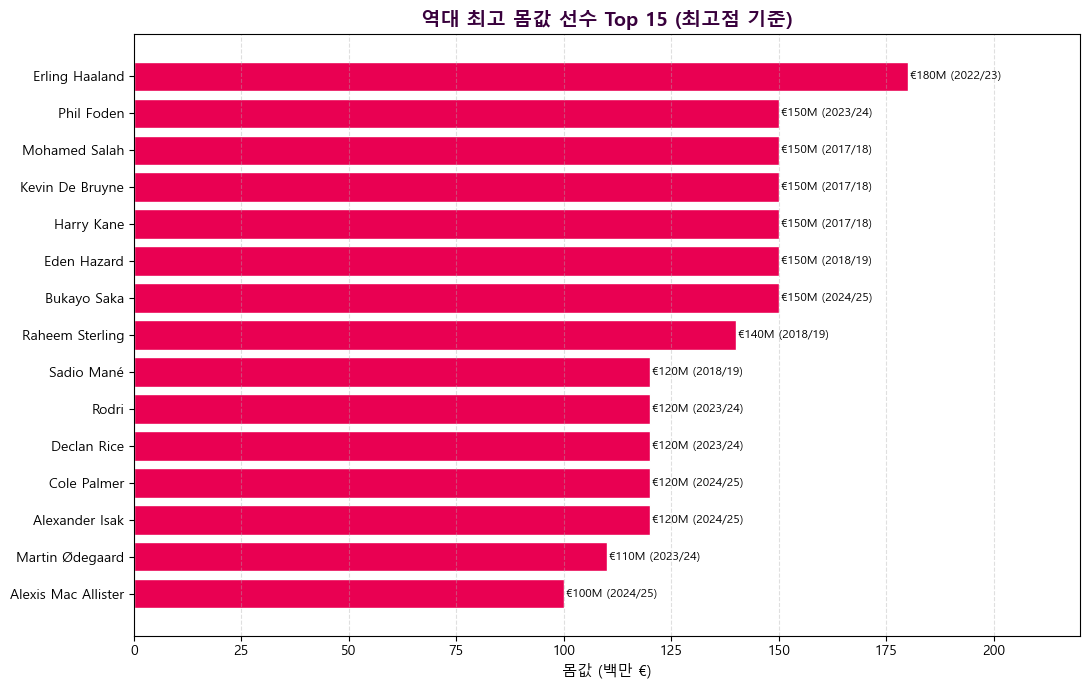

저장: 5_2_top15_market_value.png


In [25]:
# ── 5-2. 역대 최고 몸값 선수 Top 15 ───────────────────────────────────────
try:
    ps_top = player_season[player_season['market_value'] > 0].copy()
    ps_top_idx = ps_top.groupby('player')['market_value'].idxmax()
    ps_top_players = ps_top.loc[ps_top_idx].nlargest(15, 'market_value')
    ps_top_players = ps_top_players.sort_values('market_value')
    ps_top_players['mv_M'] = ps_top_players['market_value'] / 1e6

    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(ps_top_players['player'], ps_top_players['mv_M'],
                   color=EPL_MAGENTA, edgecolor='white')
    for bar, (_, row) in zip(bars, ps_top_players.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"€{row['mv_M']:.0f}M ({row['season']})",
                va='center', fontsize=8.5)
    ax.set_title('역대 최고 몸값 선수 Top 15 (최고점 기준)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('몸값 (백만 €)', fontsize=11)
    ax.set_xlim(0, ps_top_players['mv_M'].max() + 40)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/5_2_top15_market_value.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 5_2_top15_market_value.png")
except Exception as e:
    print(f"[건너뜀] 역대 최고 몸값 선수: {e}")


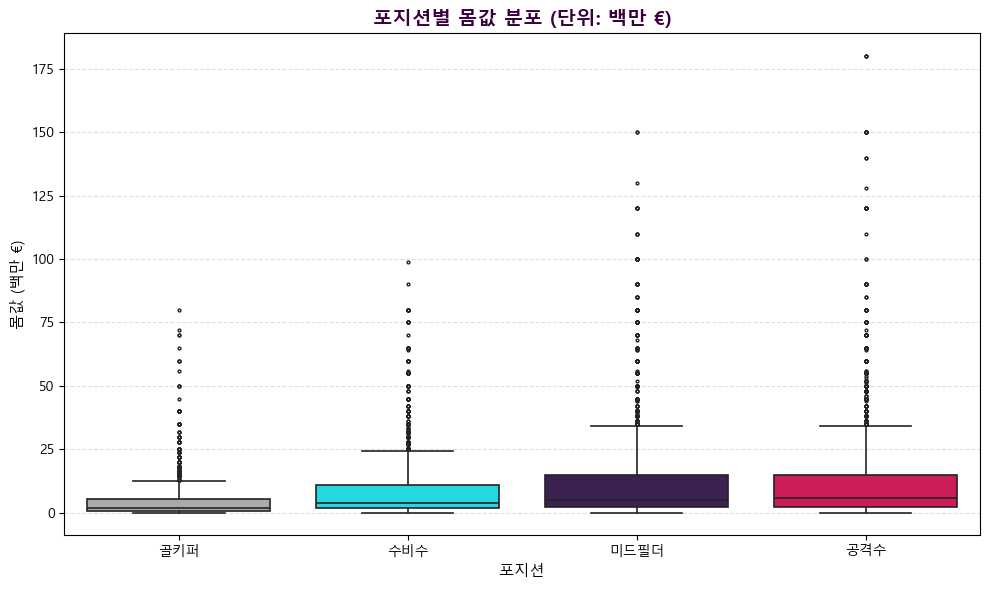

저장: 5_3_position_market_value_box.png


In [26]:
# ── 5-3. 포지션별 몸값 분포 (Box plot) ─────────────────────────────────────
try:
    ps_mv3 = player_season[player_season['market_value'] > 0].copy()
    pos_map_tm = {
        'Goalkeeper':'골키퍼',
        'Centre-Back':'센터백','Right-Back':'라이트백','Left-Back':'레프트백',
        'Defensive Midfield':'수비형MF','Central Midfield':'센트럴MF',
        'Attacking Midfield':'공격형MF','Right Midfield':'라이트MF','Left Midfield':'레프트MF',
        'Right Winger':'라이트윙','Left Winger':'레프트윙',
        'Second Striker':'세컨드스트라이커','Striker':'스트라이커',
        'Centre-Forward':'센터포워드','Midfielder':'미드필더',
    }
    pos_group_map = {
        'Goalkeeper':'골키퍼',
        'Centre-Back':'수비수','Right-Back':'수비수','Left-Back':'수비수',
        'Defensive Midfield':'미드필더','Central Midfield':'미드필더',
        'Attacking Midfield':'미드필더','Right Midfield':'미드필더','Left Midfield':'미드필더',
        'Right Winger':'공격수','Left Winger':'공격수',
        'Second Striker':'공격수','Striker':'공격수','Centre-Forward':'공격수','Midfielder':'미드필더',
    }
    ps_mv3['pos_group_kor'] = ps_mv3['position'].map(pos_group_map)
    ps_mv3 = ps_mv3[ps_mv3['pos_group_kor'].notna()].copy()
    ps_mv3['mv_M'] = ps_mv3['market_value'] / 1e6
    order_mv = ['골키퍼','수비수','미드필더','공격수']
    pal_mv = {'골키퍼':'#AAAAAA','수비수':EPL_CYAN,'미드필더':EPL_PURPLE,'공격수':EPL_MAGENTA}

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=ps_mv3, x='pos_group_kor', y='mv_M', order=order_mv,
                palette=pal_mv, ax=ax, fliersize=2, linewidth=1.2)
    ax.set_title('포지션별 몸값 분포 (단위: 백만 €)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('포지션', fontsize=11)
    ax.set_ylabel('몸값 (백만 €)', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/5_3_position_market_value_box.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 5_3_position_market_value_box.png")
except Exception as e:
    print(f"[건너뜀] 포지션별 몸값 분포: {e}")


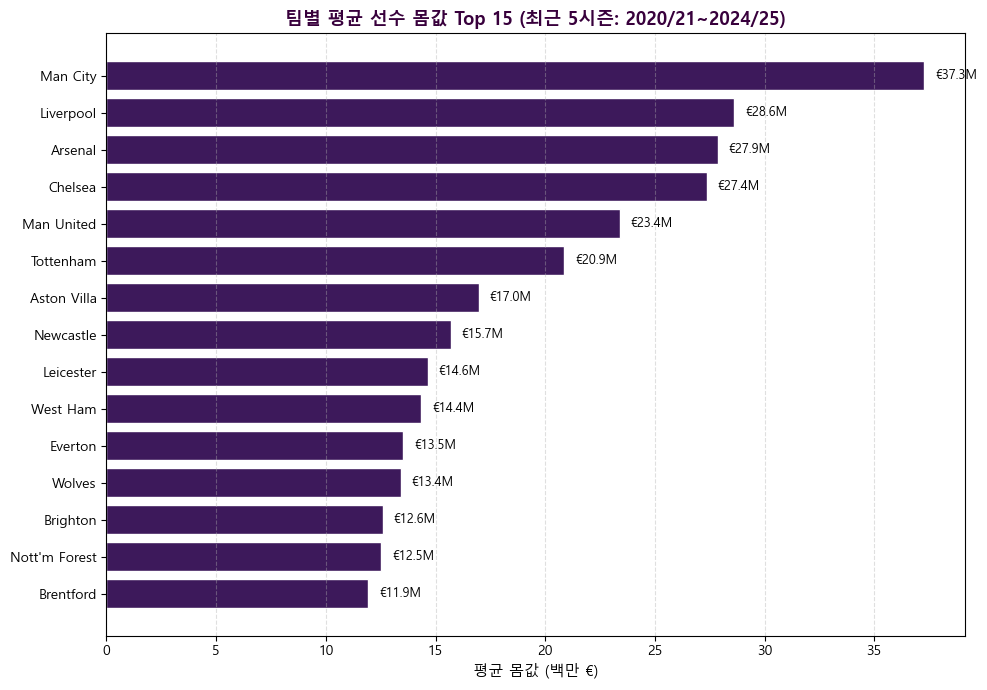

저장: 5_4_team_avg_market_value.png


In [27]:
# ── 5-4. 팀별 평균 몸값 Top 15 (최근 5시즌) ───────────────────────────────
try:
    ps_mv4 = player_season[player_season['market_value'] > 0].copy()
    recent_seasons = sorted(ps_mv4['season'].unique())[-5:]
    ps_recent = ps_mv4[ps_mv4['season'].isin(recent_seasons)].copy()
    team_mv = ps_recent.groupby('team')['market_value'].mean().reset_index()
    team_mv['mv_M'] = team_mv['market_value'] / 1e6
    top15_teams = team_mv.nlargest(15, 'mv_M').sort_values('mv_M')

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(top15_teams['team'], top15_teams['mv_M'],
                   color=EPL_PURPLE, edgecolor='white')
    for bar, val in zip(bars, top15_teams['mv_M']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'€{val:.1f}M', va='center', fontsize=9)
    ax.set_title(f'팀별 평균 선수 몸값 Top 15 (최근 5시즌: {recent_seasons[0]}~{recent_seasons[-1]})',
                 fontsize=13, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('평균 몸값 (백만 €)', fontsize=11)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/5_4_team_avg_market_value.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 5_4_team_avg_market_value.png")
except Exception as e:
    print(f"[건너뜀] 팀별 평균 몸값: {e}")


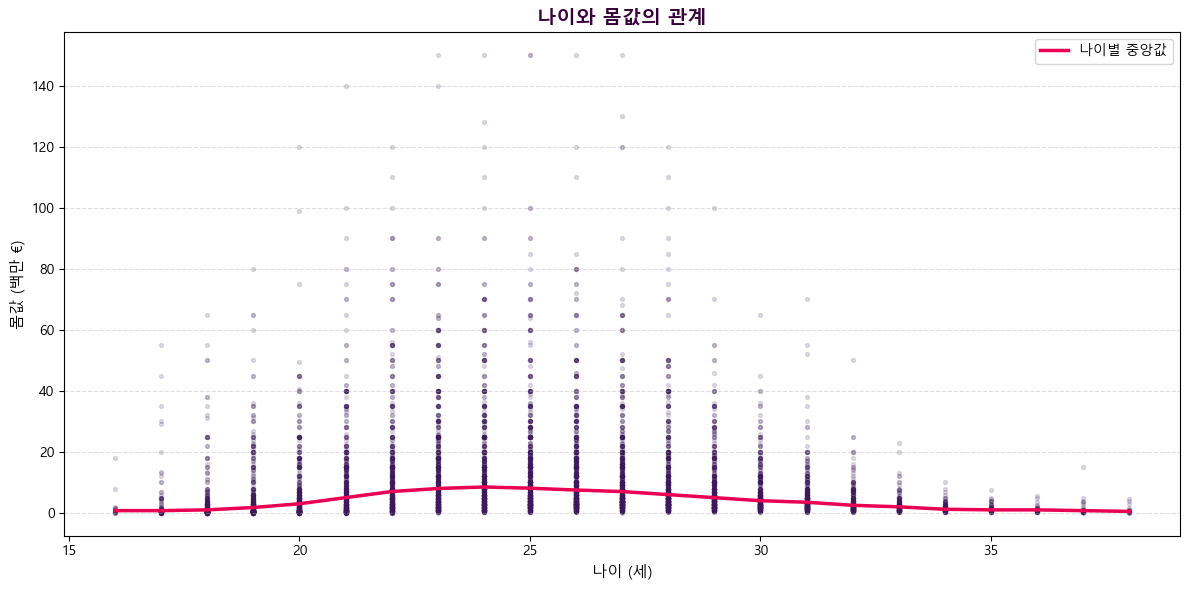

저장: 5_5_age_vs_market_value.png


In [28]:
# ── 5-5. 나이-몸값 관계 (Scatter + 추세선) ─────────────────────────────────
try:
    import numpy.polynomial.polynomial as P
    ps_mv5 = player_season[(player_season['market_value'] > 0) &
                            (player_season['age'] >= 16) &
                            (player_season['age'] <= 38)].copy()
    ps_mv5['mv_M'] = ps_mv5['market_value'] / 1e6
    # 10만 행 이상이면 샘플링
    sample = ps_mv5.sample(min(8000, len(ps_mv5)), random_state=42)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(sample['age'], sample['mv_M'], alpha=0.15, s=8,
               color=EPL_PURPLE, rasterized=True)

    # 나이별 중앙값 추세
    age_median = ps_mv5.groupby('age')['mv_M'].median().reset_index()
    ax.plot(age_median['age'], age_median['mv_M'],
            color=EPL_MAGENTA, linewidth=2.5, label='나이별 중앙값', zorder=5)

    ax.set_title('나이와 몸값의 관계', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('나이 (세)', fontsize=11)
    ax.set_ylabel('몸값 (백만 €)', fontsize=11)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/5_5_age_vs_market_value.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 5_5_age_vs_market_value.png")
except Exception as e:
    print(f"[건너뜀] 나이-몸값 관계: {e}")


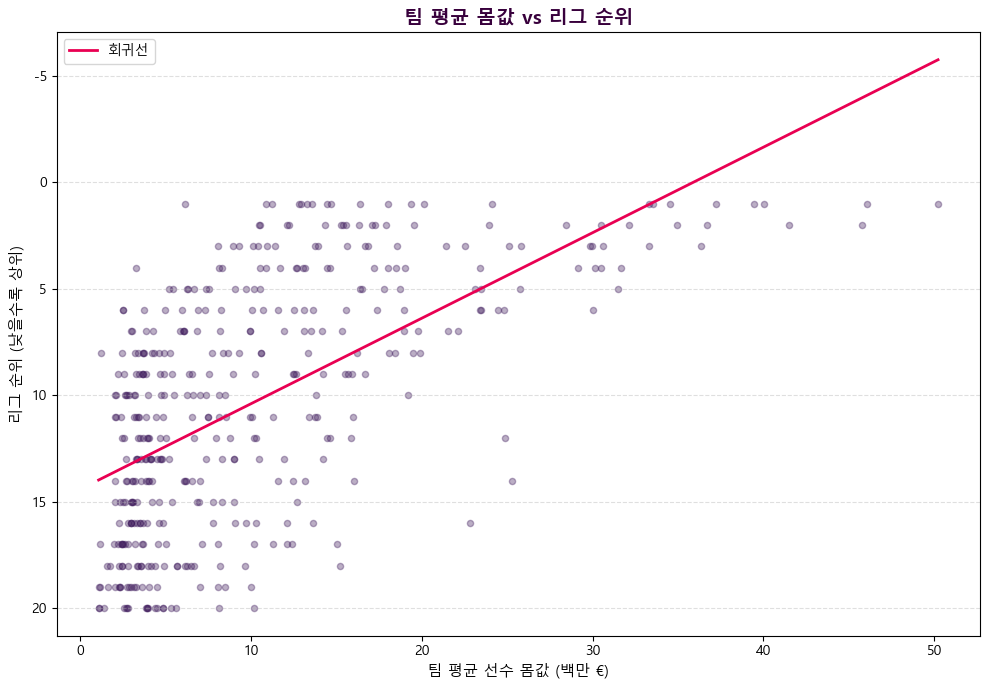

저장: 5_6_market_value_vs_rank.png


In [29]:
# ── 5-6. 몸값과 팀 순위 상관관계 (Scatter + 회귀) ───────────────────────────
try:
    ts_mv = team_season.copy()
    ts_mv['rank'] = ts_mv.groupby('Season')['points'].rank(ascending=False, method='min')

    ps_team_mv = player_season[player_season['market_value'] > 0].copy()
    team_avg_mv = ps_team_mv.groupby(['team', 'season'])['market_value'].mean().reset_index()
    team_avg_mv.columns = ['team', 'Season', 'avg_mv']
    team_avg_mv['avg_mv_M'] = team_avg_mv['avg_mv'] / 1e6

    merged = ts_mv.merge(team_avg_mv, on=['team', 'Season'])

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(merged['avg_mv_M'], merged['rank'], alpha=0.35, s=20,
               color=EPL_PURPLE, rasterized=True)

    # 회귀선
    from numpy.polynomial.polynomial import polyfit
    mask = merged['avg_mv_M'].notna() & merged['rank'].notna()
    coefs = np.polyfit(merged.loc[mask, 'avg_mv_M'], merged.loc[mask, 'rank'], 1)
    xline = np.linspace(merged['avg_mv_M'].min(), merged['avg_mv_M'].max(), 100)
    ax.plot(xline, np.polyval(coefs, xline), color=EPL_MAGENTA, linewidth=2, label='회귀선')

    ax.set_title('팀 평균 몸값 vs 리그 순위', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('팀 평균 선수 몸값 (백만 €)', fontsize=11)
    ax.set_ylabel('리그 순위 (낮을수록 상위)', fontsize=11)
    ax.invert_yaxis()
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/5_6_market_value_vs_rank.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 5_6_market_value_vs_rank.png")
except Exception as e:
    print(f"[건너뜀] 몸값-순위 상관관계: {e}")


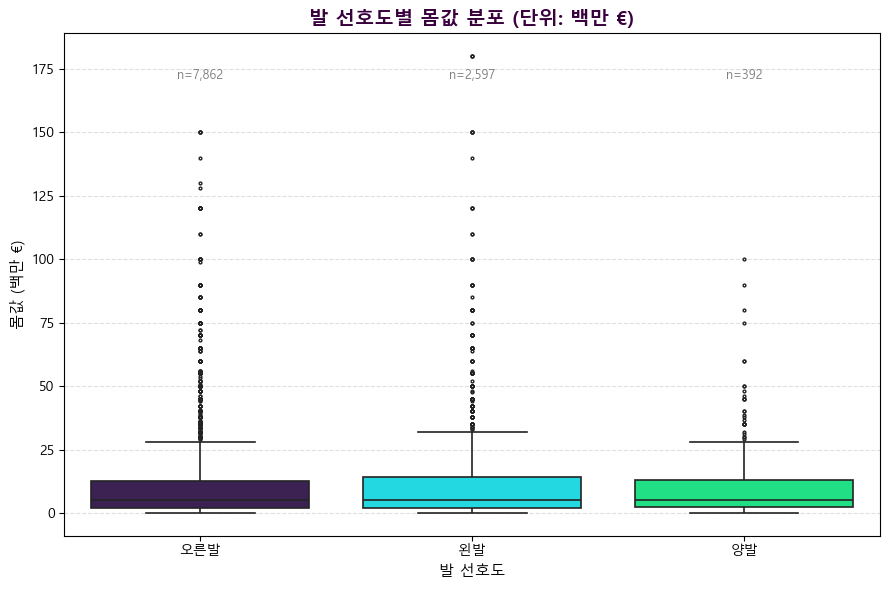

저장: 5_7_foot_market_value.png


In [30]:
# ── 5-7. 발 선호도별 몸값 분포 (Box plot) ──────────────────────────────────
try:
    ps_mv7 = player_season[(player_season['market_value'] > 0) &
                            (player_season['foot'].notna())].copy()
    foot_kor = {'right':'오른발','left':'왼발','both':'양발'}
    ps_mv7['foot_kor'] = ps_mv7['foot'].map(foot_kor)
    ps_mv7 = ps_mv7[ps_mv7['foot_kor'].notna()].copy()
    ps_mv7['mv_M'] = ps_mv7['market_value'] / 1e6
    foot_order = ['오른발','왼발','양발']
    pal_foot = {'오른발':EPL_PURPLE,'왼발':EPL_CYAN,'양발':EPL_GREEN}

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=ps_mv7, x='foot_kor', y='mv_M', order=foot_order,
                palette=pal_foot, ax=ax, fliersize=2, linewidth=1.2)
    ax.set_title('발 선호도별 몸값 분포 (단위: 백만 €)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('발 선호도', fontsize=11)
    ax.set_ylabel('몸값 (백만 €)', fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    # 그룹별 카운트 표시
    for i, foot in enumerate(foot_order):
        cnt = (ps_mv7['foot_kor'] == foot).sum()
        ax.text(i, ps_mv7['mv_M'].max() * 0.95, f'n={cnt:,}',
                ha='center', fontsize=9, color='grey')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/5_7_foot_market_value.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 5_7_foot_market_value.png")
except Exception as e:
    print(f"[건너뜀] 발 선호도별 몸값: {e}")


---
## 6. 시대별 비교

2000-2012 초기 시대와 2013-2025 현대 시대의 스탯 차이를 분석합니다.


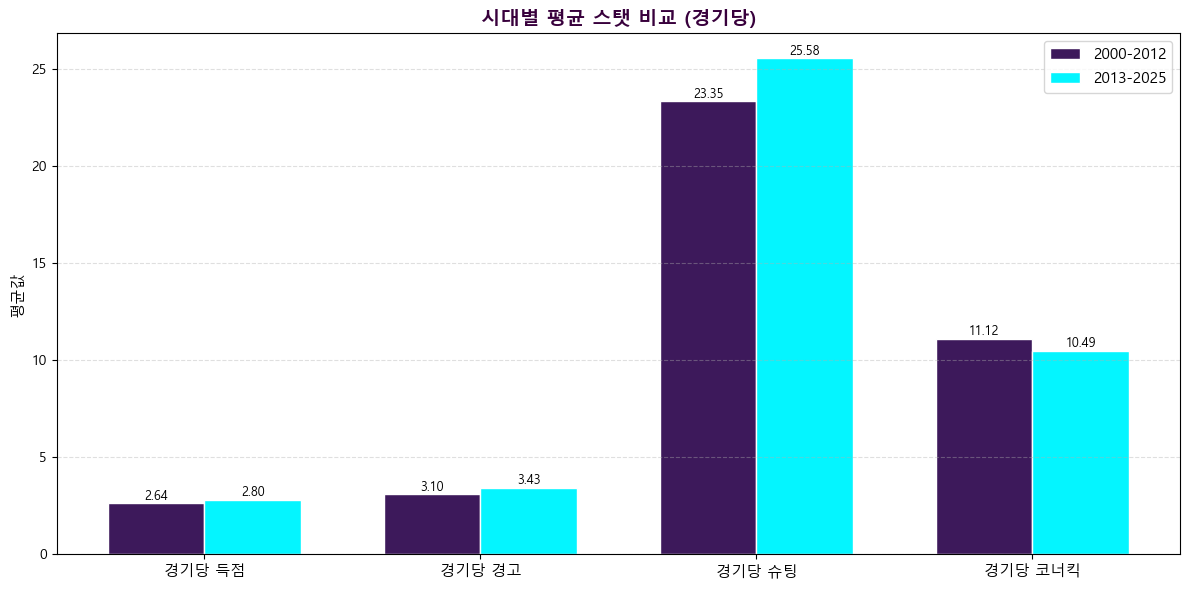

저장: 6_1_era_comparison_bar.png


In [31]:
# ── 6-1. 2000-2012 vs 2013-2025 평균 스탯 비교 (Grouped bar) ───────────────
try:
    mr_era = match_results.copy()
    mr_era['year'] = mr_era['Season'].str[:4].astype(int)
    mr_era['era'] = mr_era['year'].apply(lambda y: '2000-2012' if y < 2013 else '2013-2025')
    mr_era['total_goals'] = mr_era['FullTimeHomeGoals'] + mr_era['FullTimeAwayGoals']
    mr_era['total_yellow'] = mr_era['HomeYellowCards'] + mr_era['AwayYellowCards']
    mr_era['total_shots']  = mr_era['HomeShots'] + mr_era['AwayShots']
    mr_era['total_corners']= mr_era['HomeCorners'] + mr_era['AwayCorners']

    stat_cols = ['total_goals', 'total_yellow', 'total_shots', 'total_corners']
    stat_kor  = {'total_goals':'경기당 득점','total_yellow':'경기당 경고',
                 'total_shots':'경기당 슈팅','total_corners':'경기당 코너킥'}
    era_means = mr_era.groupby('era')[stat_cols].mean()

    x = np.arange(len(stat_cols))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, era_means.loc['2000-2012', stat_cols],
                   width, label='2000-2012', color=EPL_PURPLE, edgecolor='white')
    bars2 = ax.bar(x + width/2, era_means.loc['2013-2025', stat_cols],
                   width, label='2013-2025', color=EPL_CYAN, edgecolor='white')

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([stat_kor[c] for c in stat_cols], fontsize=11)
    ax.set_title('시대별 평균 스탯 비교 (경기당)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_ylabel('평균값', fontsize=11)
    ax.legend(fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/6_1_era_comparison_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 6_1_era_comparison_bar.png")
except Exception as e:
    print(f"[건너뜀] 시대별 스탯 비교: {e}")


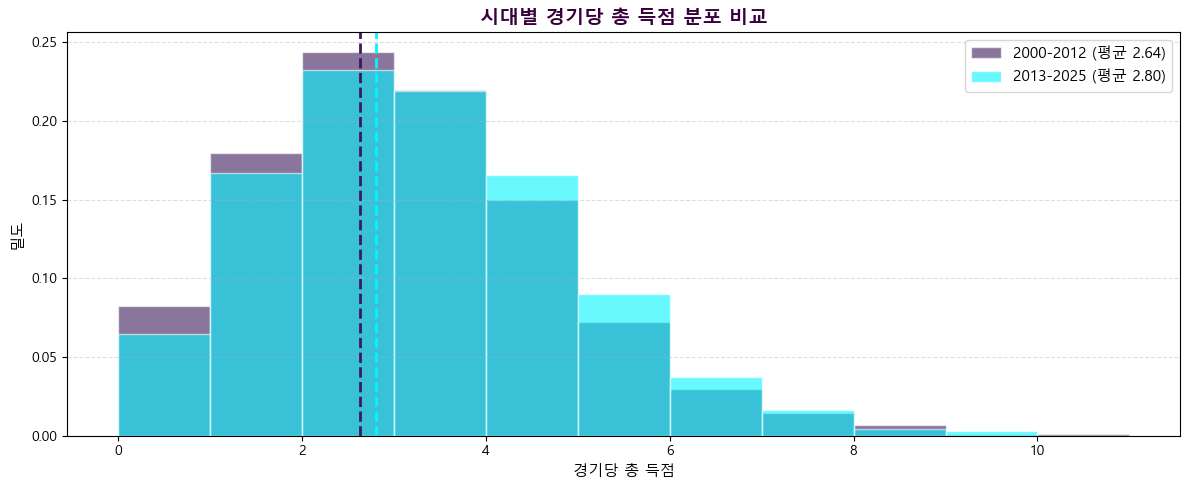

저장: 6_2_era_goals_dist.png


In [32]:
# ── 6-2. 시대별 득점 분포 변화 (겹치는 히스토그램) ─────────────────────────
try:
    mr_era2 = match_results.copy()
    mr_era2['year'] = mr_era2['Season'].str[:4].astype(int)
    mr_era2['total_goals'] = mr_era2['FullTimeHomeGoals'] + mr_era2['FullTimeAwayGoals']
    era1 = mr_era2[mr_era2['year'] < 2013]['total_goals']
    era2 = mr_era2[mr_era2['year'] >= 2013]['total_goals']

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(era1, bins=range(0, 12), alpha=0.6, color=EPL_PURPLE, edgecolor='white',
            density=True, label=f'2000-2012 (평균 {era1.mean():.2f})')
    ax.hist(era2, bins=range(0, 12), alpha=0.6, color=EPL_CYAN, edgecolor='white',
            density=True, label=f'2013-2025 (평균 {era2.mean():.2f})')
    ax.axvline(era1.mean(), color=EPL_PURPLE, linestyle='--', linewidth=2)
    ax.axvline(era2.mean(), color=EPL_CYAN,   linestyle='--', linewidth=2)
    ax.set_title('시대별 경기당 총 득점 분포 비교', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('경기당 총 득점', fontsize=11)
    ax.set_ylabel('밀도', fontsize=11)
    ax.legend(fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/6_2_era_goals_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 6_2_era_goals_dist.png")
except Exception as e:
    print(f"[건너뜀] 시대별 득점 분포: {e}")


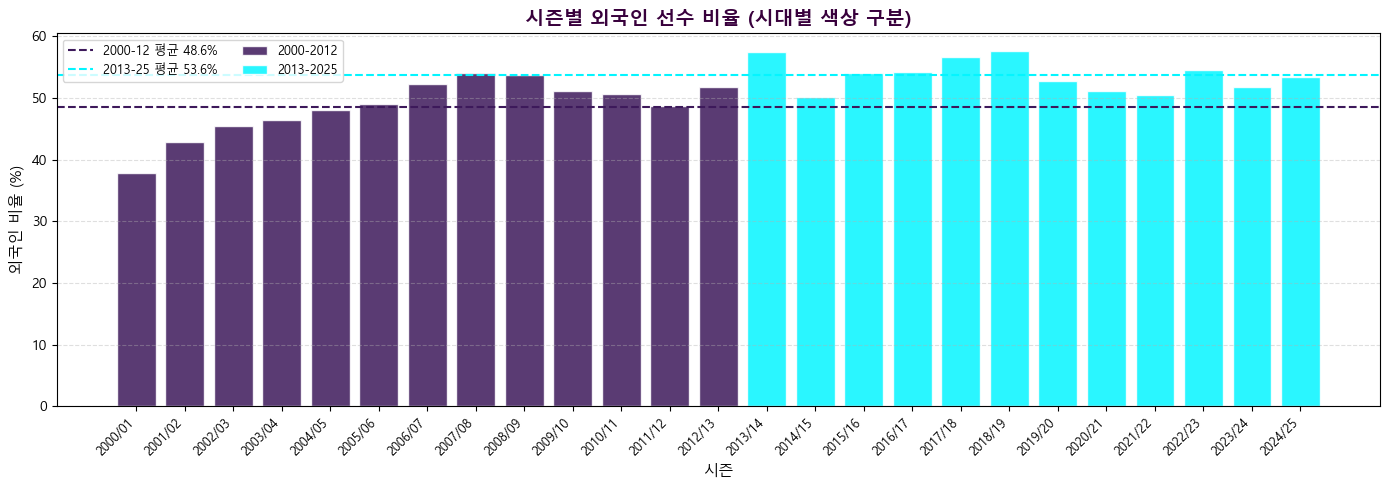

저장: 6_3_era_foreign_ratio.png


In [33]:
# ── 6-3. 시대별 외국인 비율 변화 (Grouped bar) ──────────────────────────────
try:
    ps_era3 = player_season.copy()
    ps_era3['nation_code'] = ps_era3['nation'].fillna('').str.extract(r'([A-Z]{3})')
    ps_era3['is_foreign'] = ~ps_era3['nation_code'].isin(['ENG','SCO','WAL','NIR','IRL'])
    ps_era3['year'] = ps_era3['season'].str[:4].astype(int)
    ps_era3['era'] = ps_era3['year'].apply(lambda y: '2000-2012' if y < 2013 else '2013-2025')

    era_foreign = ps_era3.groupby(['era','season']).apply(
        lambda x: x['is_foreign'].sum() / len(x) * 100
    ).reset_index()
    era_foreign.columns = ['era', 'season', 'foreign_pct']

    fig, ax = plt.subplots(figsize=(14, 5))
    colors_era = {'2000-2012': EPL_PURPLE, '2013-2025': EPL_CYAN}
    for era, grp in era_foreign.groupby('era'):
        grp = grp.sort_values('season')
        ax.bar(grp['season'], grp['foreign_pct'], color=colors_era[era],
               label=era, edgecolor='white', alpha=0.85)

    era_means3 = era_foreign.groupby('era')['foreign_pct'].mean()
    ax.axhline(era_means3.get('2000-2012', 0), color=EPL_PURPLE, linestyle='--', linewidth=1.5,
               label=f"2000-12 평균 {era_means3.get('2000-2012',0):.1f}%")
    ax.axhline(era_means3.get('2013-2025', 0), color=EPL_CYAN, linestyle='--', linewidth=1.5,
               label=f"2013-25 평균 {era_means3.get('2013-2025',0):.1f}%")

    ax.set_xticklabels(era_foreign['season'].unique(), rotation=45, ha='right', fontsize=9)
    ax.set_title('시즌별 외국인 선수 비율 (시대별 색상 구분)', fontsize=14, fontweight='bold', color=EPL_DARK)
    ax.set_xlabel('시즌', fontsize=11)
    ax.set_ylabel('외국인 비율 (%)', fontsize=11)
    ax.legend(fontsize=9, ncol=2)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/6_3_era_foreign_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 6_3_era_foreign_ratio.png")
except Exception as e:
    print(f"[건너뜀] 시대별 외국인 비율: {e}")


---
## 7. 상관관계 분석

주요 수치형 변수 간의 피어슨 상관계수 히트맵입니다.


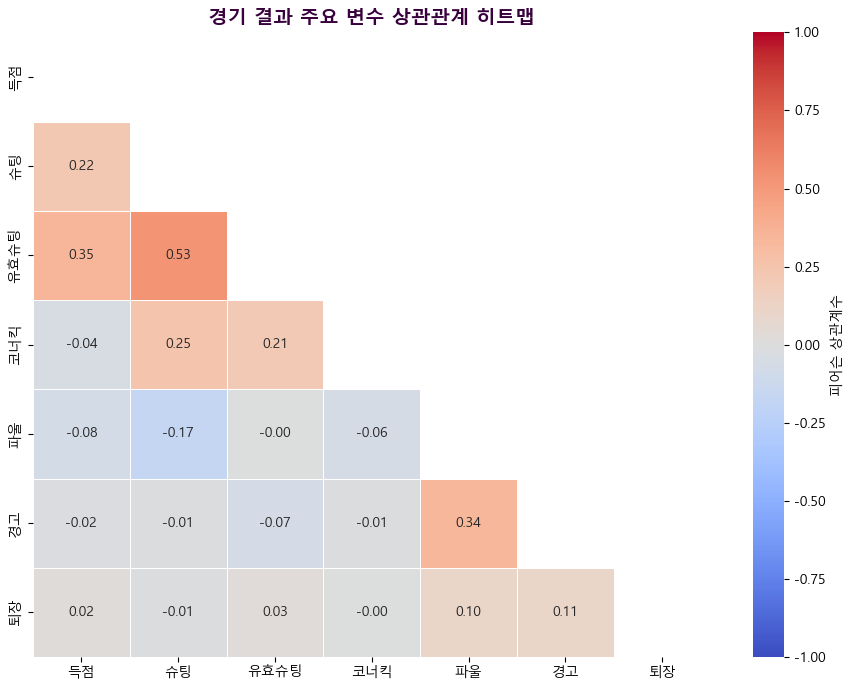

저장: 7_1_match_corr_heatmap.png


In [34]:
# ── 7-1. 경기 결과 주요 변수 상관관계 히트맵 ──────────────────────────────
try:
    mr_corr = match_results.copy()
    mr_corr['total_goals']  = mr_corr['FullTimeHomeGoals'] + mr_corr['FullTimeAwayGoals']
    mr_corr['total_yellow'] = mr_corr['HomeYellowCards'] + mr_corr['AwayYellowCards']
    mr_corr['total_red']    = mr_corr['HomeRedCards'] + mr_corr['AwayRedCards']
    mr_corr['total_shots']  = mr_corr['HomeShots'] + mr_corr['AwayShots']
    mr_corr['total_sot']    = mr_corr['HomeShotsOnTarget'] + mr_corr['AwayShotsOnTarget']
    mr_corr['total_corners']= mr_corr['HomeCorners'] + mr_corr['AwayCorners']
    mr_corr['total_fouls']  = mr_corr['HomeFouls'] + mr_corr['AwayFouls']

    corr_cols = ['total_goals','total_shots','total_sot','total_corners',
                 'total_fouls','total_yellow','total_red']
    col_kor7 = {'total_goals':'득점','total_shots':'슈팅','total_sot':'유효슈팅',
                'total_corners':'코너킥','total_fouls':'파울','total_yellow':'경고','total_red':'퇴장'}
    corr_df = mr_corr[corr_cols].rename(columns=col_kor7).corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                mask=mask, ax=ax, linewidths=0.5, annot_kws={'size': 10},
                cbar_kws={'label': '피어슨 상관계수'})
    ax.set_title('경기 결과 주요 변수 상관관계 히트맵', fontsize=14, fontweight='bold', color=EPL_DARK)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/7_1_match_corr_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 7_1_match_corr_heatmap.png")
except Exception as e:
    print(f"[건너뜀] 경기 결과 상관관계 히트맵: {e}")


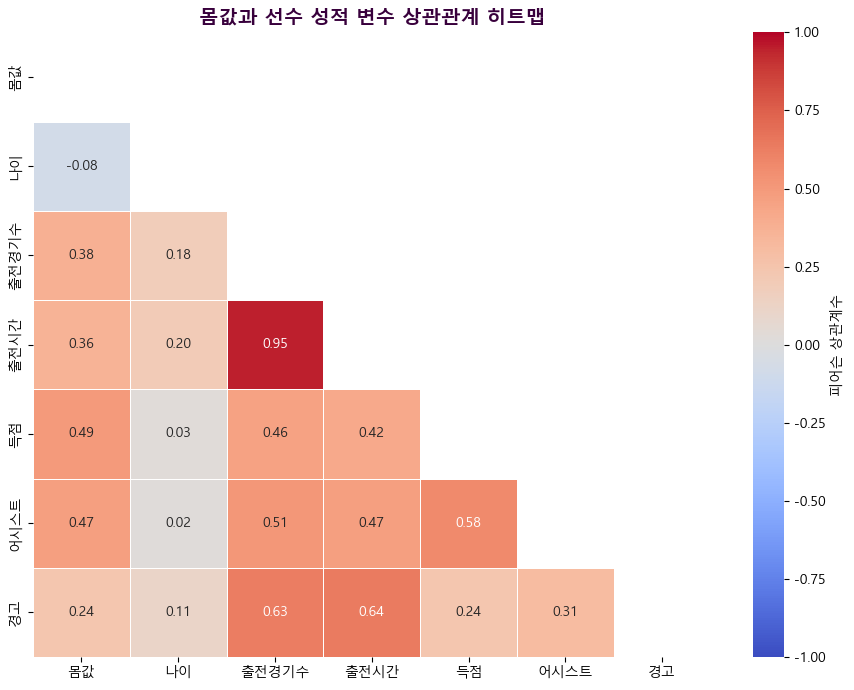

저장: 7_2_player_corr_heatmap.png


In [35]:
# ── 7-2. 몸값과 성적 변수 상관관계 히트맵 ──────────────────────────────────
try:
    ps_corr = player_season[player_season['market_value'] > 0].copy()
    ps_corr['gls_safe']  = ps_corr['gls'].fillna(0)
    ps_corr['ast_safe']  = ps_corr['ast'].fillna(0)
    ps_corr['min_safe']  = ps_corr['min'].fillna(0)
    ps_corr['crdy_safe'] = ps_corr['crdy'].fillna(0)
    ps_corr['mp_safe']   = ps_corr['mp'].fillna(0)

    corr_cols2 = ['market_value', 'age', 'mp_safe', 'min_safe', 'gls_safe', 'ast_safe', 'crdy_safe']
    col_kor2 = {'market_value':'몸값', 'age':'나이', 'mp_safe':'출전경기수',
                'min_safe':'출전시간', 'gls_safe':'득점', 'ast_safe':'어시스트', 'crdy_safe':'경고'}
    corr_df2 = ps_corr[corr_cols2].rename(columns=col_kor2).corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    mask2 = np.triu(np.ones_like(corr_df2, dtype=bool))
    sns.heatmap(corr_df2, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                mask=mask2, ax=ax, linewidths=0.5, annot_kws={'size': 10},
                cbar_kws={'label': '피어슨 상관계수'})
    ax.set_title('몸값과 선수 성적 변수 상관관계 히트맵', fontsize=14, fontweight='bold', color=EPL_DARK)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/7_2_player_corr_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: 7_2_player_corr_heatmap.png")
except Exception as e:
    print(f"[건너뜀] 몸값-성적 상관관계 히트맵: {e}")


---
## 8. 요약 및 주요 인사이트

### 📊 매치 결과
- EPL 25시즌 9,380경기 평균 득점은 **약 2.7~2.8골/경기**로 최근 상승 추세
- 홈 어드밴티지는 평균 **약 45% 홈승률**이나, COVID-19 무관중 시즌(2020/21)에 눈에 띄게 하락
- 가장 많이 나온 스코어라인은 **1-0, 1-1, 2-1, 2-0** 순
- 경고카드는 2000년대 중반 정점 후 감소 추세 (VAR 도입 영향 추정)
- 경기는 **토요일**에 가장 많이 열림 (전체의 약 45%)

### 🏟️ 팀 분석
- **Man City, Chelsea, Arsenal, Liverpool, Man United**가 통산 승률 Top 5
- 46개 팀 중 25시즌 전체 참가 팀은 **Arsenal, Chelsea, Everton, Liverpool, Man United, Tottenham** 6팀
- 빅6 순위에서 Man City의 지배력이 2010년대 이후 압도적으로 증가
- 역대 최고 포인트는 Man City 2017/18 시즌 **100점**

### 👤 선수 스탯
- 선수 평균 나이 **약 25세**, 피크 나이대는 22~27세
- 영국 외 외국인 비율이 2000년대 초 약 **55%**에서 2020년대 **70%** 이상으로 증가
- 통산 최다 득점자는 **Harry Kane(213골)**, Wayne Rooney(208골), Mohamed Salah(186골)

### 💰 몸값 분석
- 유효 몸값 데이터는 2004/05 시즌 이후 급격히 증가
- 역대 최고 몸값은 Erling Haaland **1억 8천만 유로** (2022/23)
- 공격수 > 미드필더 > 수비수 > 골키퍼 순으로 평균 몸값 높음
- 팀 평균 몸값과 리그 순위 간 **강한 음의 상관관계** 존재

### 📅 시대 비교
- 2013-2025년 시대가 2000-2012년보다 경기당 득점 소폭 증가
- 경고카드는 감소, 코너킥 수도 감소 (빌드업 전술 변화 반영)
- 외국인 선수 비율 시대별 지속 상승


In [36]:
print("=" * 60)
print("✅ EPL EDA 노트북 실행 완료!")
print("=" * 60)
import os
figs = [f for f in os.listdir(FIG_DIR) if f.endswith('.png')]
print(f"\n저장된 시각화 파일 ({len(figs)}개):")
for f in sorted(figs):
    print(f"  {f}")


✅ EPL EDA 노트북 실행 완료!

저장된 시각화 파일 (64개):
  1_1_season_avg_goals.png
  1_2_result_stacked_bar.png
  1_3_home_advantage.png
  1_4_top_scorelines.png
  1_5_cards_by_season.png
  1_6_matches_by_weekday.png
  2_1_top10_win_rate.png
  2_2_team_season_count.png
  2_3_big6_rank.png
  2_4_champion_points.png
  2_5_promoted_survival.png
  3_1_age_distribution.png
  3_2_position_count.png
  3_3_nationality_top20.png
  3_4_foreign_player_ratio.png
  3_5_top20_scorers.png
  3_6_pos_goals_assists_boxplot.png
  4_1_start_vs_sub.png
  4_2_minutes_distribution.png
  4_3_stats_by_position_box.png
  4_4_data_availability_heatmap.png
  4_5_radar_chart.png
  5_1_avg_market_value.png
  5_2_top15_market_value.png
  5_3_position_market_value_box.png
  5_4_team_avg_market_value.png
  5_5_age_vs_market_value.png
  5_6_market_value_vs_rank.png
  5_7_foot_market_value.png
  6_1_era_comparison_bar.png
  6_2_era_goals_dist.png
  6_3_era_foreign_ratio.png
  7_1_match_corr_heatmap.png
  7_2_player_corr_heatmap.png
  c